# Sample-Mix, Map-Level and Neighborhood Diagnostics (+ Seed-Variance Study)

**Part 1 (this run, executed):** evaluation-only diagnostics of the 12-fold year-holdout CV models, old (v2 run set)
and v4 (expanded quiet dates), both scored on the **full v4 held-out years** -- no retraining.
Script: `scripts/diagnose_sample_mix.py`; results: `models/cv_year_holdout_v4/sample_mix_diagnostics.json`;
cached per-cell scores: `data/interim/diag_scores/`.

The questions, each motivated by a concern raised after the v4 CV showed *no* gain from the extra quiet data:

1. **Sample-mix artifacts.** The run-selection design gives a skewed sample mix: 70% of quiet samples are initialized
   at 20Z while only 11% of active samples are, and active runs are anchored at the earliest report so positives skew
   to short lead (bin 0 has 2x the positives of bin 1). Does skill survive when those factors are held fixed?
2. **Map-level discrimination.** Cell-pooled AUC-PR is a blunt instrument for what the extra quiet data was supposed to
   improve (rejecting quiet days). Does the max predicted probability separate active from quiet maps, and where do
   false alarms concentrate?
3. **Neighborhood-dilated verification.** The 39 km cell is a strict verification unit. If a tornado within *k* cells
   counts as a hit (scores unchanged), how do the metrics move?

**Part 2 (executed, last sections):** a seed-variance study -- retraining the recipe with different seeds on three
folds -- plus ensemble follow-ups, to put an error bar on every comparison in this project. Headline: **seed noise is
about as large as the signal in every single-seed comparison made so far, and averaging models is the largest gain found
to date.**

**Part 3 (executed, after Part 2):** a day-block bootstrap asking whether the seed swings are model instability or just
test-sampling noise in the metric -- answer: both are real, and the models are genuinely unstable.

**Update after Part 5:** plain-model seed spread is ~19% when pooled over nine seeds (the ~24% in Parts 2-3 came from three seeds on selected folds), and a direct 4-member plain-ensemble test is a near miss (8.2% gap) rather than the extrapolated pass; Part 5c recalibrates those numbers. Parts 2-4 stand as measured at the time.

**Update after Part 6:** with six seeds per fold, weight averaging helps less than Part 5 first showed (partial, not "works"); three averaged members just meet the Part 4 stability criterion and three plain members do not.

**Reading guide:** raw AUC-PR depends strongly on prevalence (positive rate), so strata with different prevalence are
compared by *lift* (AUC-PR / positive rate) -- a within-stratum yardstick only, since lift itself falls as prevalence
rises.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd().parent
DIAG = REPO_ROOT / "models" / "cv_year_holdout_v4" / "sample_mix_diagnostics.json"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"
C_OLD, C_NEW = "#7fb3d5", "#f5b041"

F = json.loads(DIAG.read_text())["folds"]
years = [f["year"] for f in F]
print(f"{len(F)} folds: {years}")

def arr(tag, sect, name, key):
    return np.array([f[tag][sect][name].get(key, np.nan) for f in F], float)

def paired(a, b, label, fmt=".4f", names=("old", "v4")):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = ~(np.isnan(a) | np.isnan(b))
    d = b[ok] - a[ok]
    p = stats.ttest_rel(b[ok], a[ok]).pvalue if ok.sum() > 2 else float("nan")
    print(f"{label:46s} {names[0]} {np.mean(a[ok]):{fmt}} -> {names[1]} {np.mean(b[ok]):{fmt}}  "
          f"(diff {d.mean():+{fmt}}, {names[1]} wins {(d > 0).sum()}/{ok.sum()}, paired-t p={p:.4f})")

12 folds: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Sample-mix artifacts

### 1a. The mix itself (per held-out year)

In [2]:
mix = pd.DataFrame([{"year": f["year"], **f["mix"]} for f in F]).set_index("year")
mix.columns = ["frac_init_20Z", "active_frac@20Z", "active_frac@not20Z", "active_frac@bin0", "active_frac@bin1", "frac_quiet_date_runs"]
display(mix.round(3))
print(mix.mean().round(3).to_string())

,frac_init_20Z,active_frac@20Z,active_frac@not20Z,active_frac@bin0,active_frac@bin1,frac_quiet_date_runs
year,,,,,,
2014,0.692,0.035,0.719,0.327,0.163,0.644
2015,0.486,0.098,0.719,0.570,0.265,0.419
2016,0.465,0.096,0.660,0.560,0.235,0.396
2017,0.406,0.097,0.718,0.621,0.309,0.344
2018,0.448,0.118,0.692,0.607,0.262,0.366
2019,0.388,0.122,0.687,0.655,0.281,0.323
2020,0.486,0.087,0.691,0.555,0.240,0.418
2021,0.471,0.137,0.689,0.590,0.268,0.379
2022,0.477,0.085,0.688,0.559,0.241,0.417


frac_init_20Z           0.463
active_frac@20Z         0.109
active_frac@not20Z      0.694
active_frac@bin0        0.583
active_frac@bin1        0.258
frac_quiet_date_runs    0.390


P(active) is ~11% at 20Z but ~69% at other init hours, and ~58% in bin 0 vs. ~26% in bin 1. A model could in
principle use time-of-day cues (diurnal t2m/CAPE) as a shortcut for "this map is probably active". The test: does skill
(relative to base rate) collapse when restricted to 20Z, where both active and quiet maps are ordinary?

### 1b. Skill by stratum -- raw AUC-PR vs. lift

In [3]:
names = ["all", "init20z", "init_not20z", "bin0", "bin1", "init20z_bin0", "init20z_bin1"]
rows = []
for n in names:
    for tag in ("old", "v4"):
        rows.append({
            "stratum": n, "model": tag,
            "mean_n_samples": np.nanmean(arr(tag, "subsets", n, "n_samples")),
            "pos_rate": np.nanmean(arr(tag, "subsets", n, "pos_rate")),
            "auc_pr": np.nanmean(arr(tag, "subsets", n, "auc_pr")),
            "lift": np.nanmean(arr(tag, "subsets", n, "lift")),
            "best_f1": np.nanmean(arr(tag, "subsets", n, "f1_at_best_f1")),
            "n_years": int(np.sum(~np.isnan(arr(tag, "subsets", n, "auc_pr")))),
        })
strata = pd.DataFrame(rows)
display(strata.round({"pos_rate": 7, "auc_pr": 4, "lift": 0, "best_f1": 3, "mean_n_samples": 0}))

,stratum,model,mean_n_samples,pos_rate,auc_pr,lift,best_f1,n_years
0,all,old,820.0,0.000139,0.0461,333.0,0.114,12
1,all,v4,820.0,0.000139,0.0442,321.0,0.115,12
2,init20z,old,368.0,0.000031,0.0207,684.0,0.072,12
3,init20z,v4,368.0,0.000031,0.0217,689.0,0.075,12
4,init_not20z,old,452.0,0.000231,0.0502,215.0,0.120,12
5,init_not20z,v4,452.0,0.000231,0.0481,206.0,0.120,12
6,bin0,old,410.0,0.000185,0.0590,333.0,0.138,12
7,bin0,v4,410.0,0.000185,0.0578,328.0,0.139,12
8,bin1,old,410.0,0.000093,0.0355,370.0,0.096,12
9,bin1,v4,410.0,0.000093,0.0341,368.0,0.097,12


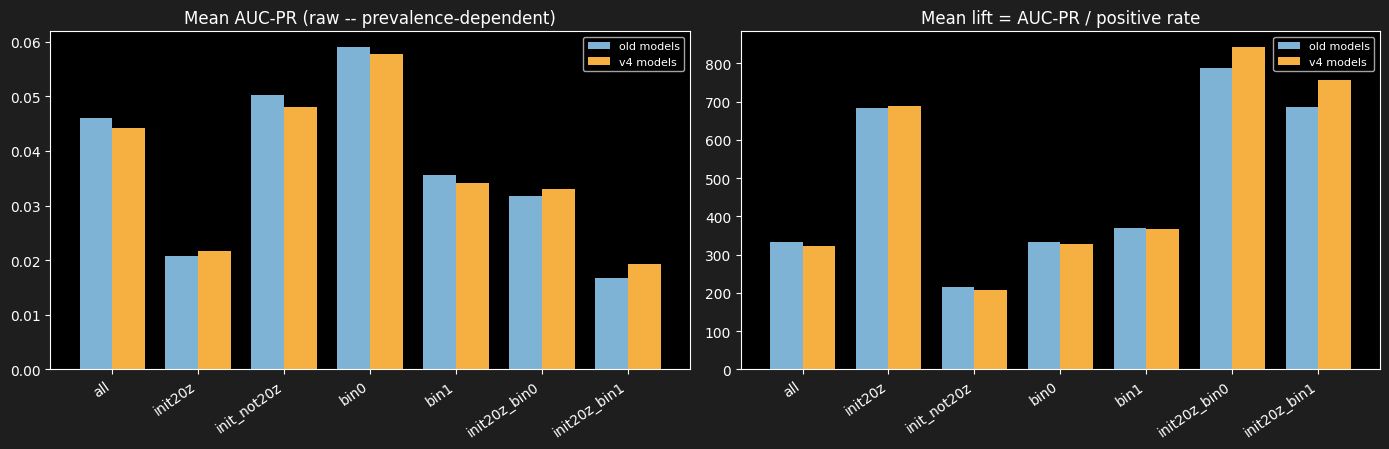

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(names)); w = 0.38
for ax, key, title in ((axes[0], "auc_pr", "Mean AUC-PR (raw -- prevalence-dependent)"), (axes[1], "lift", "Mean lift = AUC-PR / positive rate")):
    for off, tag, col in ((-w/2, "old", C_OLD), (w/2, "v4", C_NEW)):
        v = [strata[(strata.stratum == n) & (strata.model == tag)][key].iloc[0] for n in names]
        ax.bar(x + off, v, w, color=col, label=f"{tag} models")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=35, ha="right"); ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** Restricting to 20Z cuts the positive rate ~4.4x (1.4e-4 -> 3.1e-5) and raw AUC-PR roughly halves, but
**lift goes up, not down** (~690x vs. ~320x). Skill relative to base rate does not collapse where a time-of-day shortcut is
unavailable. Likewise bin 1 has half the positives of bin 0 and lower raw AUC-PR, but equal-or-higher lift: the model's
skill does not fade with lead time out to 8 hours. Old and v4 models behave identically in every stratum.

Caveat: this shows the shortcut is not *needed* for skill, not that the model never uses it; and lift is not
prevalence-invariant, so cross-stratum lift differences are suggestive, not exact.

### 1c. Per-year lift, 20Z vs. everything (v4 models)

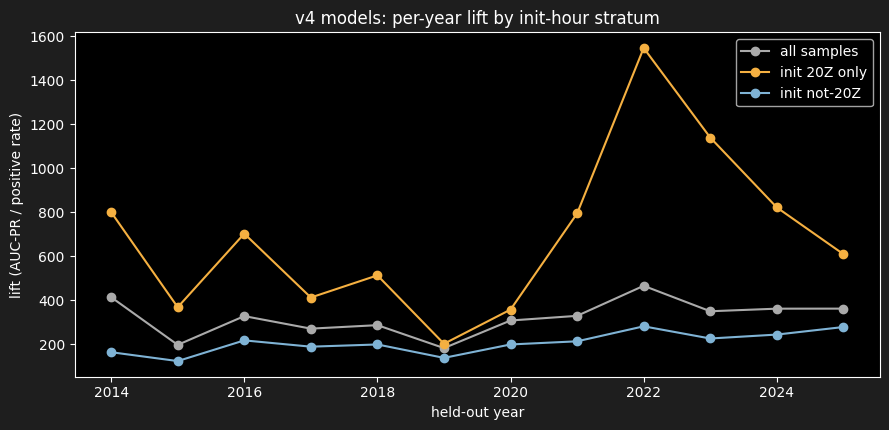

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for n, col, lab in (("all", "#aaaaaa", "all samples"), ("init20z", C_NEW, "init 20Z only"), ("init_not20z", C_OLD, "init not-20Z")):
    ax.plot(years, arr("v4", "subsets", n, "lift"), marker="o", color=col, label=lab)
ax.set_xlabel("held-out year"); ax.set_ylabel("lift (AUC-PR / positive rate)")
ax.set_title("v4 models: per-year lift by init-hour stratum"); ax.legend(); plt.tight_layout(); plt.show()

### 1d. A deployment-like expectation

A real all-hourly-runs stream has ~17% active maps and a per-cell positive rate near 5e-5. The 20Z stratum (11% active,
3.1e-5) is the closest proxy available in this data -- imperfect, since 20Z active samples are a particular subset of days.

In [6]:
p20 = np.nanmean(arr("v4", "subsets", "init20z", "pos_rate"))
a20 = arr("v4", "subsets", "init20z", "auc_pr"); aall = arr("v4", "subsets", "all", "auc_pr")
print(f"CV mix (all samples):  mean AUC-PR {np.mean(aall):.4f} +/- {np.std(aall):.4f}   (pos rate {np.nanmean(arr('v4','subsets','all','pos_rate')):.2e})")
print(f"20Z stratum (proxy):   mean AUC-PR {np.mean(a20):.4f} +/- {np.std(a20):.4f}   (pos rate {p20:.2e})")
print(f"-> deployment-like raw AUC-PR expectation ~{np.mean(a20):.3f} (not {np.mean(aall):.3f}); interpret as ~0.02-0.03")

CV mix (all samples):  mean AUC-PR 0.0442 +/- 0.0142   (pos rate 1.39e-04)
20Z stratum (proxy):   mean AUC-PR 0.0217 +/- 0.0131   (pos rate 3.13e-05)
-> deployment-like raw AUC-PR expectation ~0.022 (not 0.044); interpret as ~0.02-0.03


## 2. Map-level discrimination: can the model tell an active map from a quiet one?

Per map, the score is the maximum predicted probability over all cells; the label is "any positive cell". False-alarm
rate (FAR) is the fraction of quiet maps whose max score reaches the threshold that catches a given fraction (recall) of
active maps. Quiet maps are split into **quiet-date runs** (a run where neither bin is active -- ordinary quiet days, the
new data's target) and **quiet bins of active runs** (the other bin of a run that has a tornado -- same synoptic day).

In [7]:
keys = [
    ("active_frac", "fraction of maps active"),
    ("map_auc_roc", "map AUC-ROC"), ("map_auc_pr", "map AUC-PR"), ("map_lift", "map lift"),
    ("far_all_quiet@recall0.5", "FAR, all quiet maps, 50% recall"), ("far_all_quiet@recall0.8", "FAR, all quiet maps, 80% recall"),
    ("far_quietdate_runs@recall0.5", "FAR, quiet-DATE runs, 50% recall"), ("far_quietdate_runs@recall0.8", "FAR, quiet-DATE runs, 80% recall"),
    ("far_quiet_bins_of_active_runs@recall0.5", "FAR, quiet bins of ACTIVE runs, 50%"), ("far_quiet_bins_of_active_runs@recall0.8", "FAR, quiet bins of ACTIVE runs, 80%"),
    ("within_active_auc_pr", "AUC-PR within active maps only"), ("within_active_lift", "lift within active maps only"),
]
for k, lab in keys:
    o = [f["old"]["map_level"].get(k, np.nan) for f in F]; n = [f["v4"]["map_level"].get(k, np.nan) for f in F]
    paired(o, n, lab)

fraction of maps active                        old 0.4206 -> v4 0.4206  (diff +0.0000, v4 wins 0/12, paired-t p=nan)
map AUC-ROC                                    old 0.8052 -> v4 0.7942  (diff -0.0111, v4 wins 4/12, paired-t p=0.2699)
map AUC-PR                                     old 0.7231 -> v4 0.7140  (diff -0.0091, v4 wins 3/12, paired-t p=0.4478)
map lift                                       old 1.7693 -> v4 1.7480  (diff -0.0214, v4 wins 3/12, paired-t p=0.4568)
FAR, all quiet maps, 50% recall                old 0.1352 -> v4 0.1490  (diff +0.0138, v4 wins 8/12, paired-t p=0.3425)
FAR, all quiet maps, 80% recall                old 0.3420 -> v4 0.3569  (diff +0.0149, v4 wins 8/12, paired-t p=0.3426)
FAR, quiet-DATE runs, 50% recall               old 0.0547 -> v4 0.0617  (diff +0.0070, v4 wins 6/12, paired-t p=0.5540)
FAR, quiet-DATE runs, 80% recall               old 0.1895 -> v4 0.2022  (diff +0.0127, v4 wins 6/12, paired-t p=0.4866)
FAR, quiet bins of ACTIVE runs, 50%        

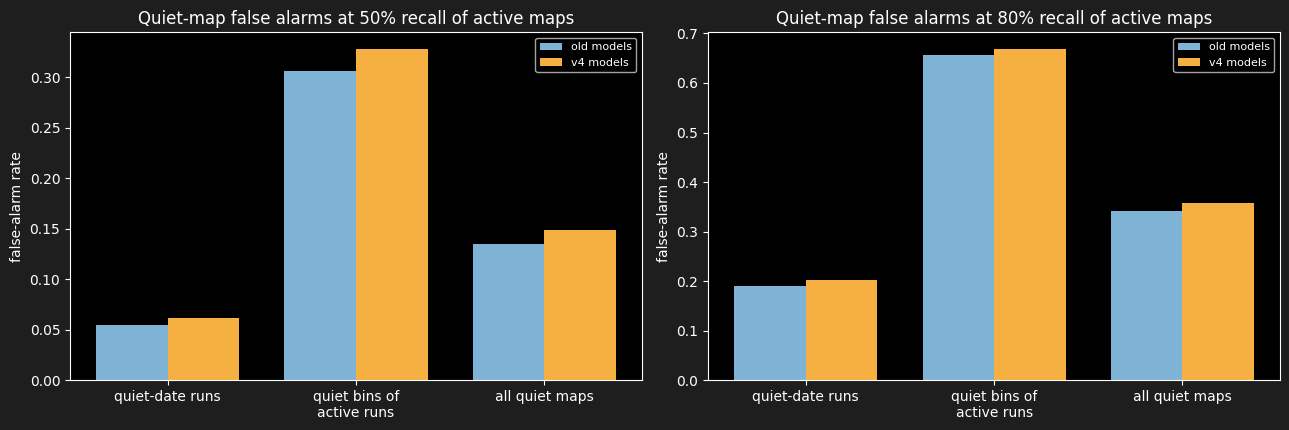

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
cats = [("far_quietdate_runs", "quiet-date runs"), ("far_quiet_bins_of_active_runs", "quiet bins of\nactive runs"), ("far_all_quiet", "all quiet maps")]
for ax, r in zip(axes, (0.5, 0.8)):
    x = np.arange(len(cats)); w = 0.38
    for off, tag, col in ((-w/2, "old", C_OLD), (w/2, "v4", C_NEW)):
        v = [np.nanmean([f[tag]["map_level"].get(f"{c}@recall{r}", np.nan) for f in F]) for c, _ in cats]
        ax.bar(x + off, v, w, color=col, label=f"{tag} models")
    ax.set_xticks(x); ax.set_xticklabels([l for _, l in cats]); ax.set_ylabel("false-alarm rate")
    ax.set_title(f"Quiet-map false alarms at {int(r*100)}% recall of active maps"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** Map-level discrimination is the weak link: AUC-ROC ~0.80 and a map AUC-PR of ~0.72 against a 42% active
rate (lift ~1.7x). False alarms concentrate on the **quiet bins of active runs** (~31-33% at 50% recall) -- the same
synoptic day, wrong time window -- not on ordinary quiet-date runs (~5-6%). The model mostly rejects boring days but
struggles with *when* during a severe day. A plausible (untested) contributor: each 4-hour bin is represented by one
start-of-bin snapshot (fxx=0 or 4), so within-bin evolution is invisible.

**The extra quiet data did not help even on the metric built to detect it:** quiet-date FAR at 50% recall is 5.5% (old) vs.
6.2% (v4), and map AUC-ROC 0.805 vs. 0.794 -- neither significant, and neither in the hoped-for direction.

## 3. Neighborhood-dilated verification

Model scores are unchanged. The verification label is dilated: a cell is positive if a tornado touched it **or any cell
within k cells** (k=1: 3x3 neighborhood, ~39 km; k=2: 5x5, ~78 km). Positive rate rises, so raw AUC-PR rises
mechanically -- read precision/recall and lift alongside it. (This is verification only; changing *training* labels to a
neighborhood definition would alter the locked labeling method and needs a separate discussion.)

In [9]:
rows = []
for k in ("k0", "k1", "k2"):
    for tag in ("old", "v4"):
        g = lambda key: np.array([f[tag]["dilation"][k][key] for f in F])
        rows.append({"tolerance": k, "model": tag, "pos_rate": g("pos_rate").mean(), "auc_pr": g("auc_pr").mean(),
                     "auc_pr_std": g("auc_pr").std(), "lift": g("lift").mean(), "best_f1": g("f1_at_best_f1").mean(),
                     "precision": g("precision_at_best_f1").mean(), "recall": g("recall_at_best_f1").mean()})
dil = pd.DataFrame(rows)
display(dil.round({"pos_rate": 6, "auc_pr": 4, "auc_pr_std": 4, "lift": 0, "best_f1": 3, "precision": 3, "recall": 3}))
for k in ("k0", "k1", "k2"):
    o = [f["old"]["dilation"][k]["auc_pr"] for f in F]; n = [f["v4"]["dilation"][k]["auc_pr"] for f in F]
    paired(o, n, f"AUC-PR {k}")

,tolerance,model,pos_rate,auc_pr,auc_pr_std,lift,best_f1,precision,recall
0,k0,old,0.000139,0.0461,0.0183,333.0,0.114,0.089,0.172
1,k0,v4,0.000139,0.0442,0.0142,321.0,0.115,0.084,0.194
2,k1,old,0.000827,0.1505,0.0387,186.0,0.244,0.202,0.316
3,k1,v4,0.000827,0.1475,0.0371,182.0,0.237,0.199,0.298
4,k2,old,0.001938,0.2129,0.0410,113.0,0.302,0.266,0.352
5,k2,v4,0.001938,0.2098,0.0462,111.0,0.295,0.259,0.349


AUC-PR k0                                      old 0.0461 -> v4 0.0442  (diff -0.0018, v4 wins 5/12, paired-t p=0.5418)
AUC-PR k1                                      old 0.1505 -> v4 0.1475  (diff -0.0030, v4 wins 5/12, paired-t p=0.6724)
AUC-PR k2                                      old 0.2129 -> v4 0.2098  (diff -0.0030, v4 wins 4/12, paired-t p=0.7349)


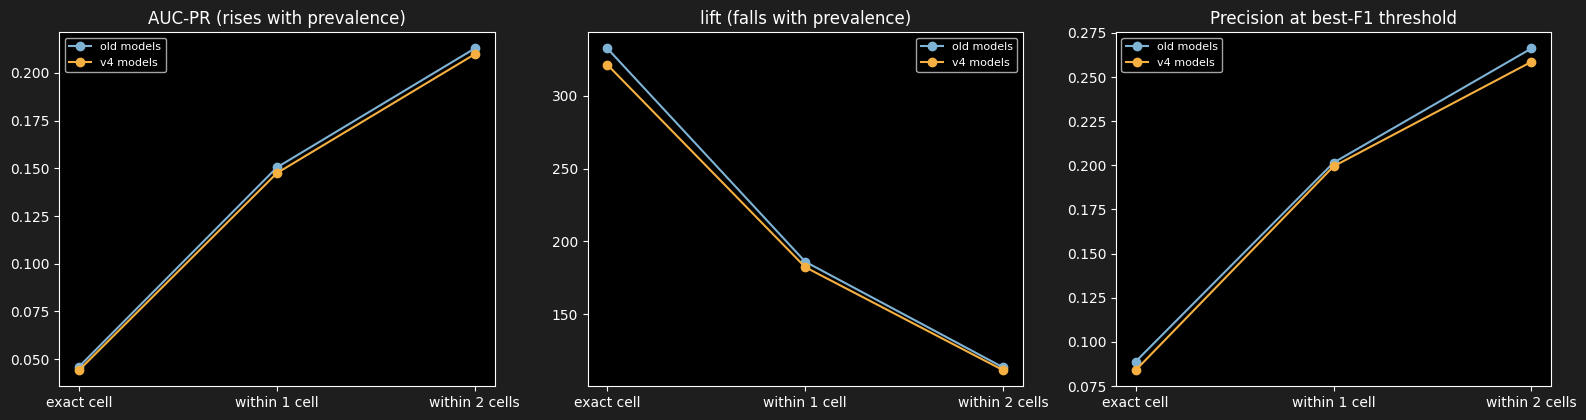

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
ks = ["k0", "k1", "k2"]; xl = ["exact cell", "within 1 cell", "within 2 cells"]
for ax, key, title in zip(axes, ("auc_pr", "lift", "precision"), ("AUC-PR (rises with prevalence)", "lift (falls with prevalence)", "Precision at best-F1 threshold")):
    for tag, col in (("old", C_OLD), ("v4", C_NEW)):
        ax.plot(xl, [dil[(dil.tolerance == k) & (dil.model == tag)][key].iloc[0] for k in ks], marker="o", color=col, label=f"{tag} models")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** Dilating by one cell multiplies the positive rate ~6x and AUC-PR ~3.3x (0.044 -> 0.148) while *lift falls*
(321x -> 182x) -- most of the headline AUC-PR rise is prevalence. The informative number is **precision at the best-F1
threshold: 8% -> 20% (k=1) -> 26% (k=2)**: roughly 12% of flagged cells are near misses within one cell of a tornado,
i.e. many exact-cell "false alarms" are spatially close. Old vs. v4 stays flat (-2.0% at k=1, p~0.67).

## Conclusions (Part 1)

- **Sample-mix artifacts do not explain the skill.** Lift is higher at 20Z-only and equal-or-higher in bin 1, so neither a
  time-of-day shortcut nor a short-lead skew is inflating ranking skill relative to base rate. But **raw AUC-PR is
  prevalence-dependent: a deployment-like stream should be expected to score ~0.02-0.03, not 0.044.**
- **Map-level discrimination is modest** (AUC-ROC ~0.80, lift 1.7x) and the errors are mostly *temporal within a severe
  day*, not ordinary-quiet-day false alarms. This points to within-bin temporal information (multi-fxx aggregation) as a
  more promising lever than more quiet days.
- **The v4 quiet-data expansion is a consistent null** across every lens here: cell AUC-PR, F1, map-level AUC, quiet-day
  FAR, and dilated verification all show differences of a few percent with p > 0.25 and no consistent direction.
- **Near-miss structure:** at 1-cell tolerance precision rises from 8% to 20%; the model is often spatially close when it
  is wrong at the exact cell.
- **Limits:** each model's own best-F1 threshold (tuned on the data it is scored on); one seed per fold; v4 test years
  only; baselines not re-scored per stratum or under dilation. The seed study below addresses the one-seed limit.

---
# Part 2: Seed-variance study and ensembles

**Why.** Every comparison in this project -- v4 vs. old (-4% AUC-PR, p~0.5), alpha settings, architectures, feature sets --
rested on a single training seed per configuration. Fold-to-fold swings of +/-25-35% between two nominally identical recipes
(v4 vs. old, same folds) suggested training noise might be a large part of what we were reading as signal. Seed noise had
never been measured here.

**Design.** The v4 14-feature U-Net CV recipe (`TornadoUNet(base_channels=16)`, alpha=0.25, gamma=2.0, 50 epochs,
`quiet_keep_fraction=0.2`), retrained with **seeds 1 and 2** on three folds -- **2016, 2020, 2024** -- chosen because the
v4-vs-old difference there was large and of mixed sign (+33%, -26%, +36%). Seed 0 is the existing v4 CV model, giving three
seeds per fold. The seed controls model initialization, quiet-map sampling, and batch shuffling; data and splits are
identical. Scripts: `scripts/run_seed_study.sh` (training), `scripts/seed_study_eval.py` (scoring + ensembles),
`scripts/ensemble_followup.py` (evaluation-only follow-ups). Results: `models/seed_study/`.

**Predictions recorded before seeing results:**
1. *Seed-to-seed spread of AUC-PR within a fold will be >= ~5% relative* -- comparable to the whole -4% old-vs-v4 gap.
2. *Fold-to-fold differences (2016 vs. 2020 vs. 2024) will exceed seed-to-seed differences.*
3. *A 3-seed ensemble (mean probability) will beat the average single seed by >5% AUC-PR.*
4. *The old+v4 two-model ensemble will behave like a two-seed ensemble* (similar gain).

**Caveat on the design, stated up front:** the three folds were *selected* for a large v4-vs-old gap, and seed 0 is one of the
three seeds. Selecting on a large gap partly selects on seed 0 having been lucky or unlucky, which can inflate the
within-fold spread. A check that excludes seed 0 is included below.

In [11]:
S_PATH = REPO_ROOT / "models" / "seed_study" / "seed_study_results.json"
E_PATH = REPO_ROOT / "models" / "seed_study" / "ensemble_followup.json"
SR = json.loads(S_PATH.read_text())["folds"]
EF = json.loads(E_PATH.read_text())
SEEDS = ["seed0", "seed1", "seed2"]
sfolds = [f["year"] for f in SR]
print("seed-study folds:", sfolds)

seed-study folds: [2016, 2020, 2024]


## 2a. Seed-to-seed spread (same recipe, same data, same test year; only the seed differs)

In [12]:
rows = []
for f in SR:
    s = np.array([f[k]["auc_pr"] for k in SEEDS])
    rows.append({"year": f["year"], "seed0": s[0], "seed1": s[1], "seed2": s[2], "mean": s.mean(), "sd": s.std(ddof=1),
                 "CV_%": 100 * s.std(ddof=1) / s.mean(), "range/mean_%": 100 * (s.max() - s.min()) / s.mean(),
                 "old_model": f["old"]["auc_pr"], "v4_seedmean_vs_old_%": 100 * (s.mean() / f["old"]["auc_pr"] - 1),
                 "seed0_vs_old_%": 100 * (s[0] / f["old"]["auc_pr"] - 1)})
seedtab = pd.DataFrame(rows)
display(seedtab.round(4))
print(f"mean within-fold CV of AUC-PR across seeds: {seedtab['CV_%'].mean():.1f}%  (per fold {seedtab['CV_%'].round(0).tolist()})")
print(f"v4 seed-mean vs old: {seedtab['v4_seedmean_vs_old_%'].round(0).tolist()} (mean {seedtab['v4_seedmean_vs_old_%'].mean():+.1f}%)   "
      f"vs. seed 0 alone: {seedtab['seed0_vs_old_%'].round(0).tolist()}")

,year,seed0,seed1,seed2,mean,sd,CV_%,range/mean_%,old_model,v4_seedmean_vs_old_%,seed0_vs_old_%
0,2016,0.0366,0.0259,0.0253,0.0292,0.0064,21.7849,38.6570,0.0274,6.6325,33.4299
1,2020,0.0387,0.0478,0.0349,0.0404,0.0066,16.3504,31.8121,0.0524,-22.8864,-26.2575
2,2024,0.0638,0.0307,0.0501,0.0482,0.0166,34.4947,68.6595,0.0468,3.0621,36.4384


mean within-fold CV of AUC-PR across seeds: 24.2%  (per fold [22.0, 16.0, 34.0])
v4 seed-mean vs old: [7.0, -23.0, 3.0] (mean -4.4%)   vs. seed 0 alone: [33.0, -26.0, 36.0]


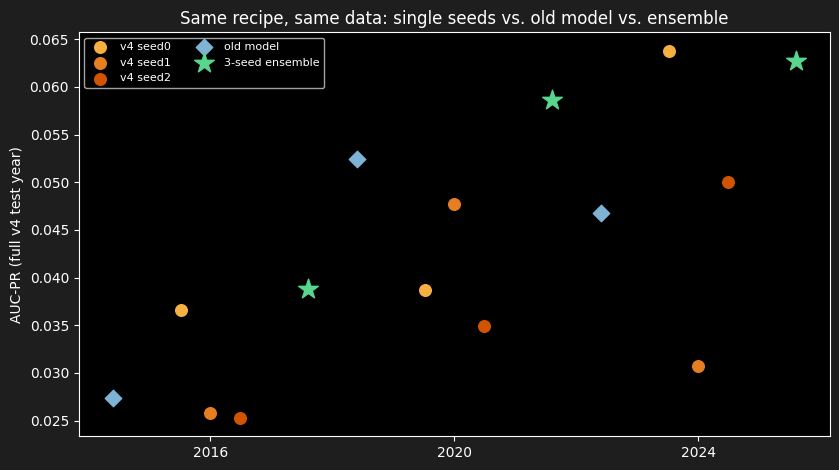

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(SR))
for j, (k, col) in enumerate(zip(SEEDS, ["#f5b041", "#e67e22", "#d35400"])):
    ax.scatter(x + (j - 1) * 0.12, [f[k]["auc_pr"] for f in SR], color=col, s=70, zorder=3, label=f"v4 {k}")
ax.scatter(x - 0.4, [f["old"]["auc_pr"] for f in SR], color=C_OLD, marker="D", s=70, zorder=3, label="old model")
ax.scatter(x + 0.4, [f["ens_seeds"]["auc_pr"] for f in SR], color="#58d68d", marker="*", s=220, zorder=3, label="3-seed ensemble")
ax.set_xticks(x); ax.set_xticklabels(sfolds); ax.set_ylabel("AUC-PR (full v4 test year)")
ax.set_title("Same recipe, same data: single seeds vs. old model vs. ensemble"); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### Variance decomposition and what a 12-fold comparison can detect

In [14]:
A = np.array([[f[k]["auc_pr"] for k in SEEDS] for f in SR])          # folds x seeds
within_var = A.var(axis=1, ddof=1).mean()
fold_means = A.mean(axis=1)
between_var_obs = fold_means.var(ddof=1)
between_var_true = max(between_var_obs - within_var / 3, 0)        # remove seed noise carried in 3-seed fold means
rel = np.sqrt(within_var) / A.mean()
print(f"within-fold seed SD (pooled):       {np.sqrt(within_var):.4f}   ({100*rel:.1f}% of mean AUC-PR)")
print(f"between-fold SD of 3-seed means:    {np.sqrt(between_var_obs):.4f}   (noise-corrected: {np.sqrt(between_var_true):.4f})")

# robustness: drop seed 0 (the fold-selection-affected member); use seeds 1 and 2 only
d = np.array([f["seed1"]["auc_pr"] - f["seed2"]["auc_pr"] for f in SR])
sd12 = np.sqrt((d ** 2 / 2).mean()); rel12 = sd12 / np.mean([[f["seed1"]["auc_pr"], f["seed2"]["auc_pr"]] for f in SR])
print(f"excluding seed 0 (seeds 1 & 2 only): seed SD {sd12:.4f} = {100*rel12:.1f}% of mean")

# the v4 single-seed 12-fold CV SD, decomposed
v4_cv_sd = np.std([EF["all_folds_old_v4"][i]["v4_seed0"]["auc_pr"] for i in range(12)], ddof=1)
print(f"12-fold single-seed v4 CV SD = {v4_cv_sd:.4f}; if seed SD ~ {np.sqrt(within_var):.4f}, implied true between-fold SD ~ "
      f"{np.sqrt(max(v4_cv_sd**2 - within_var, 0)):.4f}  (i.e. ~{100*min(within_var/v4_cv_sd**2,1):.0f}% of the observed fold-to-fold variance may be seed noise)")

# detectability: paired comparison over 12 folds, one seed per fold per arm
for label, r, n in (("single seed per fold, 12 folds", rel, 12), ("3 seeds per fold, 12 folds", rel, 36)):
    se = np.sqrt(2) * r / np.sqrt(n)
    print(f"{label:34s}: SE of mean relative diff ~{100*se:.1f}% -> minimum detectable effect (80% power, alpha .05) ~{100*2.8*se:.0f}%")
print("NB: the seed SD is estimated from only 3 folds x 3 seeds (6 degrees of freedom): its 95% interval is roughly 0.64x-2.2x the point estimate.")

within-fold seed SD (pooled):       0.0110   (27.9% of mean AUC-PR)
between-fold SD of 3-seed means:    0.0095   (noise-corrected: 0.0071)
excluding seed 0 (seeds 1 & 2 only): seed SD 0.0095 = 26.5% of mean
12-fold single-seed v4 CV SD = 0.0149; if seed SD ~ 0.0110, implied true between-fold SD ~ 0.0100  (i.e. ~54% of the observed fold-to-fold variance may be seed noise)
single seed per fold, 12 folds    : SE of mean relative diff ~11.4% -> minimum detectable effect (80% power, alpha .05) ~32%
3 seeds per fold, 12 folds        : SE of mean relative diff ~6.6% -> minimum detectable effect (80% power, alpha .05) ~18%
NB: the seed SD is estimated from only 3 folds x 3 seeds (6 degrees of freedom): its 95% interval is roughly 0.64x-2.2x the point estimate.


**Reading it.** AUC-PR varies by **~24% (CV) between seeds of the identical recipe**, with a max-min range of 32-69% of the mean
within a single fold. That is as large as every v4-vs-old difference we saw: seed 0's apparent +33% / -26% / +36% vs. the old model
becomes +7% / -23% / +3% when seed 0 is replaced by the 3-seed mean (mean -4.4%). A single-seed 12-fold comparison can only detect
an effect of roughly **30%** (3 seeds per fold: ~18%). The estimate is itself uncertain (3 folds, 6 d.f.) and the folds were
selected for large gaps, but excluding seed 0 gives a similar spread (~27%), so the conclusion does not hinge on the selection.

## 2b. Ensembles: averaging models removes much of that noise

Mean predicted probability across models, scored on the same test samples. `ens_seeds` = seeds 0-2; `ens_old_v4` = old model + seed 0;
`ens_all` = old + all three seeds.

In [15]:
metrics = [("auc_pr", "AUC-PR"), ("f1_at_best_f1", "best F1"), ("map_auc_roc", "map AUC-ROC"), ("auc_pr_k1", "AUC-PR (1-cell dilated)"),
           ("far_quietdate_runs@recall0.5", "quiet-date FAR @50% recall")]
rows = []
for k, lab in metrics:
    for f in SR:
        s = np.array([f[x][k] for x in SEEDS]); e = f["ens_seeds"][k]
        rows.append({"metric": lab, "year": f["year"], "mean_single": s.mean(), "best_single": s.max() if "far" not in k else s.min(),
                     "seed_CV_%": 100 * s.std(ddof=1) / s.mean(), "ens_3seed": e,
                     "ens_vs_mean_single_%": 100 * (e / s.mean() - 1),
                     "ens_vs_best_single_%": 100 * (e / (s.max() if "far" not in k else s.min()) - 1)})
enstab = pd.DataFrame(rows)
display(enstab.round(4))
print(enstab.groupby("metric", sort=False)[["seed_CV_%", "ens_vs_mean_single_%", "ens_vs_best_single_%"]].mean().round(1))

,metric,year,mean_single,best_single,seed_CV_%,ens_3seed,ens_vs_mean_single_%,ens_vs_best_single_%
0,AUC-PR,2016,0.0292,0.0366,21.7849,0.0388,32.5661,5.9422
1,AUC-PR,2020,0.0404,0.0478,16.3504,0.0586,44.9455,22.7396
2,AUC-PR,2024,0.0482,0.0638,34.4947,0.0628,30.2363,-1.6228
3,best F1,2016,0.0866,0.1021,15.5097,0.1112,28.3349,8.8636
4,best F1,2020,0.1071,0.1153,8.0731,0.1333,24.4179,15.5774
5,best F1,2024,0.1217,0.1466,22.6307,0.1409,15.7394,-3.9062
6,map AUC-ROC,2016,0.7487,0.7868,4.4259,0.7752,3.5458,-1.4707
7,map AUC-ROC,2020,0.7438,0.7987,6.4421,0.7755,4.2615,-2.9099
8,map AUC-ROC,2024,0.7866,0.8097,4.0685,0.8079,2.7083,-0.2206
9,AUC-PR (1-cell dilated),2016,0.1029,0.1244,18.0492,0.1278,24.1938,2.7752


                            seed_CV_%  ens_vs_mean_single_%  \
metric                                                        
AUC-PR                           24.2                  35.9   
best F1                          15.4                  22.8   
map AUC-ROC                       5.0                   3.5   
AUC-PR (1-cell dilated)          21.8                  27.6   
quiet-date FAR @50% recall       52.7                 -36.4   

                            ens_vs_best_single_%  
metric                                            
AUC-PR                                       9.0  
best F1                                      6.8  
map AUC-ROC                                 -1.5  
AUC-PR (1-cell dilated)                      4.6  
quiet-date FAR @50% recall                  33.2  


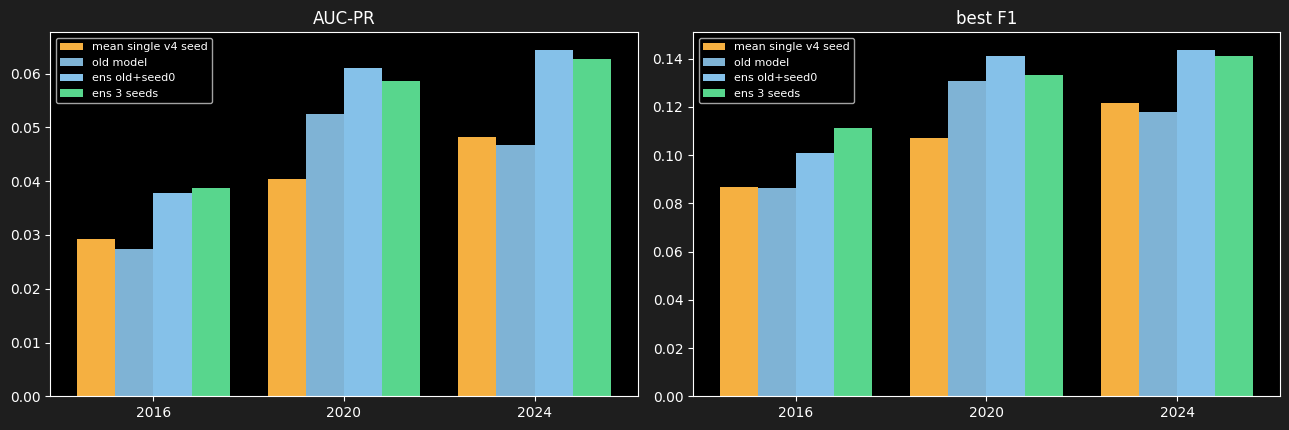

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(SR)); w = 0.2
for ax, k, title in ((axes[0], "auc_pr", "AUC-PR"), (axes[1], "f1_at_best_f1", "best F1")):
    ax.bar(x - 1.5*w, [np.mean([f[s][k] for s in SEEDS]) for f in SR], w, color="#f5b041", label="mean single v4 seed")
    ax.bar(x - 0.5*w, [f["old"][k] for f in SR], w, color=C_OLD, label="old model")
    ax.bar(x + 0.5*w, [f["ens_old_v4"][k] for f in SR], w, color="#85c1e9", label="ens old+seed0")
    ax.bar(x + 1.5*w, [f["ens_seeds"][k] for f in SR], w, color="#58d68d", label="ens 3 seeds")
    ax.set_xticks(x); ax.set_xticklabels(sfolds); ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2c. All 12 folds: the old+v4 two-model ensemble (evaluation-only, cached scores)

Every fold already has two independently trained models (old recipe, v4 seed 0), so a two-member ensemble can be scored across all 12 folds
with no retraining.

In [17]:
AF = EF["all_folds_old_v4"]
yrs = [r["year"] for r in AF]
o = np.array([r["old"]["auc_pr"] for r in AF]); v = np.array([r["v4_seed0"]["auc_pr"] for r in AF]); e = np.array([r["ens"]["auc_pr"] for r in AF])
fo = np.array([r["old"]["f1_at_best_f1"] for r in AF]); fv = np.array([r["v4_seed0"]["f1_at_best_f1"] for r in AF]); fe = np.array([r["ens"]["f1_at_best_f1"] for r in AF])
print(f"12-fold mean AUC-PR:  old {o.mean():.4f}   v4 seed0 {v.mean():.4f}   ensemble {e.mean():.4f}")
print(f"12-fold mean best-F1: old {fo.mean():.3f}   v4 seed0 {fv.mean():.3f}   ensemble {fe.mean():.3f}")
print(f"ensemble vs mean of its two members: {100*np.mean(e/((o+v)/2)-1):+.1f}%  (range {100*np.min(e/((o+v)/2)-1):+.0f}..{100*np.max(e/((o+v)/2)-1):+.0f}%); beats BOTH members in {(e > np.maximum(o, v)).sum()}/12 folds")
print(f"ensemble vs best member per fold: {100*np.mean(e/np.maximum(o, v)-1):+.1f}%")
paired(o, e, "AUC-PR old model -> ensemble", names=("old", "ens"))
paired(v, e, "AUC-PR v4 seed 0 -> ensemble", names=("seed0", "ens"))
paired(fo, fe, "best-F1 old model -> ensemble", names=("old", "ens"))
r_o = stats.pearsonr(yrs, o)[0]; r_e = stats.pearsonr(yrs, e)[0]
print(f"calendar-year trend r: old {r_o:.2f}, ensemble {r_e:.2f}")

12-fold mean AUC-PR:  old 0.0461   v4 seed0 0.0442   ensemble 0.0532
12-fold mean best-F1: old 0.114   v4 seed0 0.115   ensemble 0.124
ensemble vs mean of its two members: +18.3%  (range +10..+34%); beats BOTH members in 12/12 folds
ensemble vs best member per fold: +10.0%
AUC-PR old model -> ensemble                   old 0.0461 -> ens 0.0532  (diff +0.0072, ens wins 12/12, paired-t p=0.0002)
AUC-PR v4 seed 0 -> ensemble                   seed0 0.0442 -> ens 0.0532  (diff +0.0090, ens wins 12/12, paired-t p=0.0016)
best-F1 old model -> ensemble                  old 0.1138 -> ens 0.1237  (diff +0.0098, ens wins 11/12, paired-t p=0.0022)
calendar-year trend r: old 0.79, ensemble 0.86


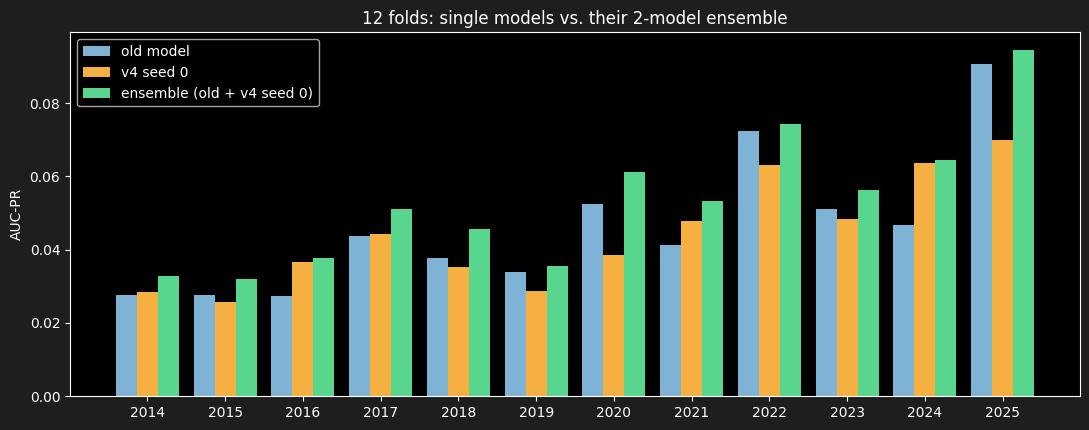

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(12); w = 0.27
ax.bar(x - w, o, w, color=C_OLD, label="old model"); ax.bar(x, v, w, color=C_NEW, label="v4 seed 0"); ax.bar(x + w, e, w, color="#58d68d", label="ensemble (old + v4 seed 0)")
ax.set_xticks(x); ax.set_xticklabels(yrs); ax.set_ylabel("AUC-PR"); ax.set_title("12 folds: single models vs. their 2-model ensemble"); ax.legend()
plt.tight_layout(); plt.show()

### 2d. Are the old-recipe and v4-recipe models exchangeable? Compare 2-member ensembles

If the old and v4 recipes were meaningfully different models, an old+seed pair should gain differently from ensembling than a seed+seed pair
(same recipe, different seed). Three folds x three pairs of each kind (9 + 9).

In [19]:
P = pd.DataFrame(EF["pairs"])
P["gain_vs_mean_members_%"] = [100 * (r.ens_auc_pr / np.mean(r.members) - 1) for r in P.itertuples()]
P["gain_vs_best_member_%"] = [100 * (r.ens_auc_pr / max(r.members) - 1) for r in P.itertuples()]
P["member_gap_%"] = [100 * abs(r.members[0] - r.members[1]) / np.mean(r.members) for r in P.itertuples()]
P["f1_gain_%"] = [100 * (r.ens_f1 / np.mean(r.members_f1) - 1) for r in P.itertuples()]
display(P.groupby("kind")[["gain_vs_mean_members_%", "gain_vs_best_member_%", "member_gap_%", "f1_gain_%"]].agg(["mean", "min", "max"]).round(1))
a = P[P.kind == "seed+seed"]["gain_vs_mean_members_%"]; b = P[P.kind == "old+seed"]["gain_vs_mean_members_%"]
print(f"pair-ensemble gain (AUC-PR): seed+seed {a.mean():+.1f}%  vs  old+seed {b.mean():+.1f}%   (Welch t-test p={stats.ttest_ind(a, b, equal_var=False).pvalue:.2f}; n=9 each, pairs share models so not independent)")

gain_vs_mean_members_%             gain_vs_best_member_%             \
                            mean   min   max                  mean  min   max   
kind                                                                            
old+seed                    26.0  11.5  40.4                  13.5  1.1  30.8   
seed+seed                   26.5   9.0  36.8                  10.1 -2.7  31.4   

          member_gap_%            f1_gain_%             
                  mean  min   max      mean  min   max  
kind                                                    
old+seed          22.4  5.9  41.4      13.5  2.3  26.3  
seed+seed         30.8  2.2  70.0      17.3  2.2  29.0

pair-ensemble gain (AUC-PR): seed+seed +26.5%  vs  old+seed +26.0%   (Welch t-test p=0.92; n=9 each, pairs share models so not independent)


## Verdicts on the pre-registered predictions

| # | prediction | verdict | evidence |
|---|---|---|---|
| 1 | seed spread >= ~5% relative | **Confirmed -- by a wide margin** | mean within-fold CV of AUC-PR 24% (16-34%); max-min range 32-69% of the fold mean |
| 2 | fold-to-fold > seed-to-seed | **Not supported** (on these 3 folds) | pooled seed SD 0.0110 vs. SD of fold means 0.0095 (0.0071 after removing seed noise). Caveat: 3 selected folds, 6 d.f. |
| 3 | 3-seed ensemble > mean single seed by >5% | **Confirmed -- by a wide margin** | AUC-PR +30% / +45% / +33% (mean +36%); best-F1 +23%; map AUC-ROC +3.5%; ensemble >= best single seed in 2 of 3 folds (+6%, +23%, -2%) |
| 4 | old+v4 ensemble behaves like a 2-seed ensemble | **Confirmed** | pair-ensemble gain +26.0% (old+seed) vs. +26.5% (seed+seed); across all 12 folds the old+v4 ensemble beats both members in 12/12 |

## Conclusions (Part 2)

1. **Single-seed AUC-PR carries roughly +/-25% noise** from seed alone (about 30% of the mean is the noise floor for a 12-fold,
   single-seed paired comparison; ~18% with 3 seeds per fold). The v4-vs-old "gain/loss" per fold was largely seed 0's luck; the
   3-seed-mean v4 vs. old is -4.4% on these folds, consistent with the 12-fold null from the CV comparison.
2. **Averaging models is the largest gain found in this project.** A 2-model ensemble improves mean 12-fold AUC-PR from 0.046/0.044 to
   0.053 (+15% / +20%; +18% vs. the mean of its members; beats both members in 12/12 folds; paired p ~ 0.0002). A 3-seed ensemble gains
   about +36% over a typical single model on the three seed-study folds. For comparison, the architecture steps in this project's history
   were +12% to +37% on single seeds, and the UH and quiet-data changes were within noise. The ensemble gain is larger than any one of them and
   costs nothing extra at inference beyond running several small U-Nets.
3. **The old and v4 recipes are exchangeable models** (pair-ensemble gains match), which independently reinforces that the quiet-data
   expansion changed nothing detectable.
4. **Noise-limited conclusions to treat as unresolved (not wrong):** every earlier single-seed ranking -- the alpha sweep, the
   architecture widening ladder, the UH ablations (single split, single seed), and Part 1's map-level and false-alarm comparisons (quiet-date
   FAR has a seed CV of ~53%) -- sits inside this noise band. Conclusions backed by large effects survive: the U-Net vs. GBT gap
   (2.1-2.9x), U-Net vs. physics baselines (~3-4x) and climatology (~30x).
5. **Implications for how to work from here:** (a) report ensembles (>= 3 seeds) as the project's headline model, and cite single-seed
   numbers only with a +/-25% caveat; (b) require >= 3 seeds per configuration, or ensemble-vs-ensemble, for any future comparison
   to be treated as a finding; (c) the true between-year spread is smaller than the single-seed CV suggests (roughly half of the observed
   12-fold variance may be seed noise), so some "year" effects, including the calendar-year skill trend, deserve a re-check on ensembles.

## Limits and what was not tested

- Seed spread is estimated from 3 folds x 3 seeds (6 d.f.); the 95% interval on the SD is wide (~0.64x-2.2x). Folds were selected for a large v4-vs-old gap (a selection effect), though excluding seed 0 gives a similar ~27% spread.
- Ensembling = plain mean of probabilities; no weighting, calibration, or rank-averaging was tried. Ensemble-vs-ensemble variance was not measured, so we do not yet know the noise floor of a 3-seed ensemble comparison (it should be lower).
- The 3-seed ensemble result covers 3 folds; only the 2-model ensemble is verified on all 12.
- Seed noise was measured for the v4 14-feature U-Net recipe; other architectures (CNN, GBT) may have different seed sensitivity.
- Same best-F1 own-threshold caveat as Part 1.

---
# Part 3: Is it model instability, or just metric noise? (day-block bootstrap)

**Question.** Part 2 found AUC-PR varies ~24% across seeds of the identical recipe. AUC-PR at a ~1e-4 positive rate is also a
noisy metric on its own (a handful of outbreak days dominate it). Which one is it?

**Method** (`scripts/bootstrap_stability.py`, `scripts/ensemble_stability.py`; no retraining, cached scores). Resample the test
year's **UTC dates** with replacement (2,000 draws; a date's samples are resampled together) and recompute AUC-PR for every
model on the *same* resample. This gives (a) the test-sampling noise of one fixed model, (b) paired intervals for differences
between two models evaluated on the same days, and (c) whether the seed spread survives resampling.

**Decision rule written before looking** (and my prior guess: a single model's resampling noise of ~10-15%, i.e. a mixed outcome):
- *Stable* if one model's resampling spread is about as large as the seed spread (~24%) and most seed-pair differences sit
  inside their paired intervals -- the swings would then mostly be the metric.
- *Unstable* if the resampling spread is clearly smaller than the seed spread and most seed pairs differ beyond their paired intervals.
- Anything in between: mixed.

In [20]:
B_PATH = REPO_ROOT / "models" / "seed_study" / "bootstrap_stability.json"
ES_PATH = REPO_ROOT / "models" / "seed_study" / "ensemble_stability.json"
BS = json.loads(B_PATH.read_text())["folds"]
ES = json.loads(ES_PATH.read_text())
print(f"{len(BS)} folds, {json.loads(B_PATH.read_text())['boots']} bootstrap draws; days per fold:", [f['n_days'] for f in BS])

12 folds, 2000 bootstrap draws; days per fold: [95, 353, 328, 353, 358, 365, 366, 365, 365, 365, 366, 284]


## 3a. How noisy is ONE fixed model's per-year AUC-PR from test-day sampling alone?

In [21]:
rows = []
for f in BS:
    for tag in ("old", "seed0", "ens_old_v4"):
        m = f["models"][tag]
        rows.append({"year": f["year"], "n_days": f["n_days"], "model": tag, "AP": m["ap"], "boot_rel_SD_%": 100 * m["boot_rel_sd"], "ci95_lo": m["ci95"][0], "ci95_hi": m["ci95"][1]})
bt = pd.DataFrame(rows)
display(bt[bt.model == "seed0"].round(4).reset_index(drop=True))
for tag in ("old", "seed0", "ens_old_v4"):
    r = bt[bt.model == tag]
    print(f"{tag:11s} mean bootstrap relative SD: all 12 folds {r['boot_rel_SD_%'].mean():.0f}%;  excluding 2014 (only {int(bt[bt.year==2014].n_days.iloc[0])} days) {r[r.year != 2014]['boot_rel_SD_%'].mean():.0f}%")

,year,n_days,model,AP,boot_rel_SD_%,ci95_lo,ci95_hi
0,2014,95,seed0,0.0285,57.8239,0.0113,0.0723
1,2015,353,seed0,0.0257,11.0202,0.0202,0.0312
2,2016,328,seed0,0.0366,19.6217,0.0255,0.0526
3,2017,353,seed0,0.0443,10.9709,0.0354,0.0540
4,2018,358,seed0,0.0352,18.2599,0.0242,0.0486
5,2019,365,seed0,0.0287,14.6814,0.0214,0.0380
6,2020,366,seed0,0.0387,30.4585,0.0185,0.0638
7,2021,365,seed0,0.0478,16.0989,0.0355,0.0653
8,2022,365,seed0,0.0630,15.2471,0.0446,0.0824
9,2023,365,seed0,0.0483,19.8858,0.0324,0.0698


old         mean bootstrap relative SD: all 12 folds 21%;  excluding 2014 (only 95 days) 16%
seed0       mean bootstrap relative SD: all 12 folds 20%;  excluding 2014 (only 95 days) 17%
ens_old_v4  mean bootstrap relative SD: all 12 folds 23%;  excluding 2014 (only 95 days) 17%


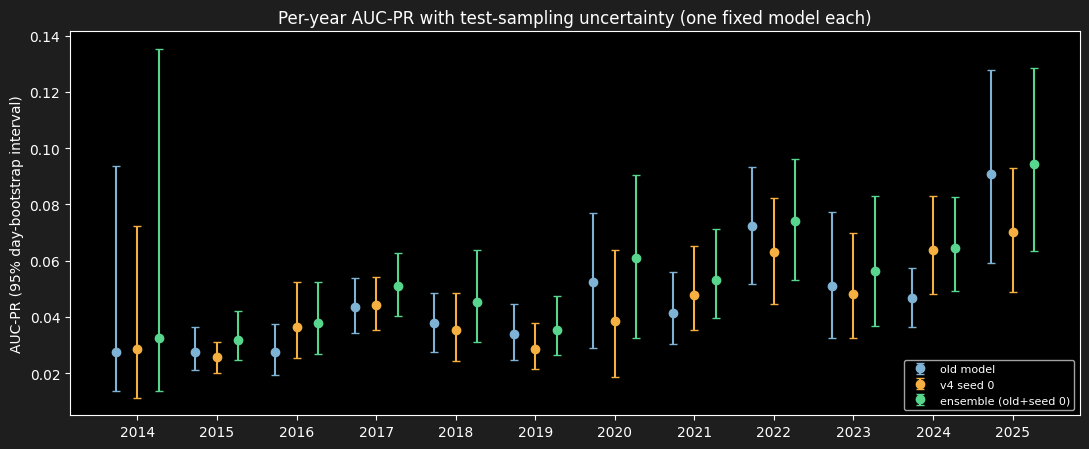

In [22]:
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(12); w = 0.27
for off, tag, col in ((-w, "old", C_OLD), (0, "seed0", C_NEW), (w, "ens_old_v4", "#58d68d")):
    ap_ = np.array([f["models"][tag]["ap"] for f in BS]); lo = np.array([f["models"][tag]["ci95"][0] for f in BS]); hi = np.array([f["models"][tag]["ci95"][1] for f in BS])
    ax.errorbar(x + off, ap_, yerr=[ap_ - lo, hi - ap_], fmt="o", color=col, capsize=3, label={"old": "old model", "seed0": "v4 seed 0", "ens_old_v4": "ensemble (old+seed 0)"}[tag])
ax.set_xticks(x); ax.set_xticklabels([f["year"] for f in BS]); ax.set_ylabel("AUC-PR (95% day-bootstrap interval)")
ax.set_title("Per-year AUC-PR with test-sampling uncertainty (one fixed model each)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** Even with the model held fixed, resampling the test days moves a year's AUC-PR by **~16% (relative SD)**, giving 95% intervals of roughly
+/-30% (e.g. 2016 old model: 0.0274, interval 0.0196-0.0375). 2014 (95 test days) is far noisier. So per-year numbers are imprecise
regardless of seed, and **ensembles do not reduce this** (below). Pooling across the 12 folds helps: ~16%/sqrt(12) ~ 5% from this source alone, if folds were independent.

## 3b. Does the seed spread survive resampling? Are seed pairs different beyond test noise?

In [23]:
rows = []
for f in BS:
    if "seed_spread_under_resampling" not in f: continue
    m, s_ = f["models"], f["seed_spread_under_resampling"]
    rows.append({"year": f["year"], "seed_APs": [round(m[f"seed{i}"]["ap"], 4) for i in range(3)], "point_seed_CV_%": 100 * s_["point_cv"],
                 "mean_seed_CV_under_resampling_%": 100 * s_["mean_cv_over_boots"], "ci95_%": [round(100 * s_["ci95_cv"][0]), round(100 * s_["ci95_cv"][1])],
                 "single-model_boot_rel_SD_%": [round(100 * m[f"seed{i}"]["boot_rel_sd"]) for i in range(3)]})
display(pd.DataFrame(rows).round(1))
rows = []
for f in BS:
    for k, v in f["paired"].items():
        if k in ("seed1-seed0", "seed2-seed0", "seed2-seed1"):
            rows.append({"year": f["year"], "pair": k, "AP_diff": v["point"], "rel_diff_%": 100 * v["rel_point"], "ci95_lo": v["ci95"][0], "ci95_hi": v["ci95"][1],
                         "differs_beyond_noise": v["excludes_zero"], "frac_resamples_same_sign": v["p_same_sign"]})
sp = pd.DataFrame(rows)
display(sp.round(4))
print(f"seed pairs that differ beyond day-resampling noise: {int(sp.differs_beyond_noise.sum())}/{len(sp)}")
op = [(f["year"], f["paired"]["seed0-old"]) for f in BS]
print(f"v4 seed 0 vs old model, all 12 folds: differ beyond noise in {sum(v['excludes_zero'] for _, v in op)}/12 folds; "
      f"signs of the significant ones: {[ '+' if v['point'] > 0 else '-' for _, v in op if v['excludes_zero']]}")

,year,seed_APs,point_seed_CV_%,mean_seed_CV_under_resampling_%,ci95_%,single-model_boot_rel_SD_%
0,2016,"[0.0366, 0.0259, 0.0253]",21.8,23.0,"[14, 33]","[20, 25, 17]"
1,2020,"[0.0387, 0.0478, 0.0349]",16.4,18.3,"[7, 32]","[30, 28, 30]"
2,2024,"[0.0638, 0.0307, 0.0501]",34.5,34.9,"[28, 42]","[14, 13, 11]"


,year,pair,AP_diff,rel_diff_%,ci95_lo,ci95_hi,differs_beyond_noise,frac_resamples_same_sign
0,2016,seed1-seed0,-0.0107,-29.3571,-0.0173,-0.0055,True,1.0000
1,2016,seed2-seed0,-0.0113,-30.8933,-0.0218,-0.0051,True,1.0000
2,2016,seed2-seed1,-0.0006,-2.1746,-0.0095,0.0046,False,0.5775
3,2020,seed1-seed0,0.0091,23.4903,0.0034,0.0195,True,1.0000
4,2020,seed2-seed0,-0.0038,-9.7761,-0.0116,0.0031,False,0.8390
5,2020,seed2-seed1,-0.0129,-26.9385,-0.0278,-0.0048,True,0.9990
6,2024,seed1-seed0,-0.0331,-51.8636,-0.0460,-0.0229,True,1.0000
7,2024,seed2-seed0,-0.0137,-21.5240,-0.0263,-0.0034,True,0.9965
8,2024,seed2-seed1,0.0194,63.0285,0.0127,0.0266,True,1.0000


seed pairs that differ beyond day-resampling noise: 7/9
v4 seed 0 vs old model, all 12 folds: differ beyond noise in 7/12 folds; signs of the significant ones: ['+', '-', '-', '+', '-', '+', '-']


**Reading it.** The seed spread is **not** a resampling artefact: it persists when the test days are resampled (mean seed CV 23% / 18% / 35% in the three folds), and **7 of 9 seed pairs
differ beyond day-resampling noise** (in most of those, every one of the 2,000 resamples has the same sign). Seeds of the same recipe produce genuinely different models on the same
test population. The two exceptions (2016 seed 1 vs. 2, 2020 seed 0 vs. 2) are within noise; 2020 has a high per-model sampling noise (~30%), so seed spread there is comparable to metric noise.
The old-vs-seed-0 comparison across 12 folds also shows 7 significant differences of **mixed sign** (3 positive, 4 negative) -- what instability, not a systematic data effect, looks like.

## 3c. Are ensembles stable? Two disjoint ensembles vs. two disjoint single models

With four independently trained models per seed fold (old, seed 0/1/2), split them into two disjoint 2-member ensembles in all 3 possible ways and compare
how far apart the two ensembles land, versus how far apart two single models land (6 pairs per fold).

In [24]:
sg = [(r["year"], p["pair"], p["rel_gap"], p["excludes_zero"]) for r in ES for p in r["single_pairs"]]
eg = [(r["year"], p["split"], p["rel_gap"], p["excludes_zero"]) for r in ES for p in r["ens_pairs"]]
print(f"single-model pairs:          mean |gap|/mean = {100*np.mean([g for _, _, g, _ in sg]):.0f}%   differ beyond resampling noise: {sum(e for *_, e in sg)}/{len(sg)}")
print(f"disjoint 2-member ensembles: mean |gap|/mean = {100*np.mean([g for _, _, g, _ in eg]):.0f}%   differ beyond resampling noise: {sum(e for *_, e in eg)}/{len(eg)}")
display(pd.DataFrame([{"year": r["year"], "single_pair_gaps_%": [round(100 * p["rel_gap"]) for p in r["single_pairs"]],
                       "ensemble_split_gaps_%": [round(100 * p["rel_gap"]) for p in r["ens_pairs"]],
                       "ensemble_APs": [[round(x, 4) for x in p["ap"]] for p in r["ens_pairs"]]} for r in ES]))
print()
print("test-sampling noise (bootstrap relative SD, %) -- singles vs. ensembles:")
for f in BS:
    if "ens_seeds" in f["models"]:
        m = f["models"]
        print(f"  {f['year']}: single seeds {[round(100*m[f'seed{i}']['boot_rel_sd']) for i in range(3)]}   3-seed ensemble {round(100*m['ens_seeds']['boot_rel_sd'])}   all-4 ensemble {round(100*m['ens_all']['boot_rel_sd'])}")
print()
for k in ("ens_old_v4-old", "ens_old_v4-seed0"):
    e_ = [f["paired"][k] for f in BS]
    print(f"2-model ensemble minus {k.split('-')[1]:6s}: gain beyond resampling noise in {sum(v['excludes_zero'] and v['point'] > 0 for v in e_)}/12 folds; "
          f"never significantly negative: {not any(v['excludes_zero'] and v['point'] < 0 for v in e_)}; mean fraction of resamples where ensemble wins {np.mean([v['p_same_sign'] for v in e_]):.2f}")

single-model pairs:          mean |gap|/mean = 27%   differ beyond resampling noise: 12/18
disjoint 2-member ensembles: mean |gap|/mean = 13%   differ beyond resampling noise: 4/9


,year,single_pair_gaps_%,ensemble_split_gaps_%,ensemble_APs
0,2016,"[29, 6, 8, 34, 37, 2]","[11, 6, 8]","[[0.0377, 0.0339], [0.0358, 0.0381], [0.0341, ..."
1,2020,"[30, 9, 40, 21, 10, 31]","[10, 33, 1]","[[0.0611, 0.0552], [0.0589, 0.0422], [0.0576, ..."
2,2024,"[31, 41, 7, 70, 24, 48]","[17, 13, 18]","[[0.0644, 0.0542], [0.0543, 0.062], [0.0539, 0..."



test-sampling noise (bootstrap relative SD, %) -- singles vs. ensembles:
  2016: single seeds [20, 25, 17]   3-seed ensemble 22   all-4 ensemble 19
  2020: single seeds [30, 28, 30]   3-seed ensemble 30   all-4 ensemble 27
  2024: single seeds [14, 13, 11]   3-seed ensemble 12   all-4 ensemble 12

2-model ensemble minus old   : gain beyond resampling noise in 8/12 folds; never significantly negative: True; mean fraction of resamples where ensemble wins 0.96
2-model ensemble minus seed0 : gain beyond resampling noise in 9/12 folds; never significantly negative: True; mean fraction of resamples where ensemble wins 0.92


**Reading it.** Two disjoint 2-member ensembles disagree by **~13%** on average, versus **~27%** for two single models, and differ beyond resampling noise in 4 of 9 cases versus 12 of 18.
So **ensembling roughly halves the instability but does not eliminate it** at two members (one split in 2020 still differs by 33%). Ensembles also do **not** reduce the test-sampling noise
(their bootstrap spread matches the singles'), and the 2-model ensemble's gain over each member holds beyond resampling noise in 8-9 of 12 folds and is never significantly negative.

## Verdict (Part 3)

- **Not "stable".** One model's per-year AUC-PR carries ~16% test-sampling noise, but seed spread is larger and survives resampling; most seed pairs are genuinely different models.
  By the rule written beforehand, this is **instability, not just metric noise** (my guess of a mixed outcome was half right: the metric noise is as large as I guessed, but the seed effect sits clearly above it).
- **Both noise sources are real and they stack:** (1) model variance across seeds (reduced by ensembling, roughly halved at 2 members); (2) test-sampling variance of the metric (not reduced by ensembling; reduced only by more test data, e.g. pooling folds).
- **Implication for the plan:** ensembling remains the right baseline -- it is the only thing tested that reduces (1) -- but a *2-member* ensemble is not yet "stable". Use more members (>= 5 is a reasonable target;
  how many are needed is untested), report **12-fold pooled** means with bootstrap intervals rather than single-year values, and consider reducing the instability at the source (EMA/SWA weight averaging, learning-rate decay, earlier stopping, gentler loss) -- none tried.
- **To verify that a larger ensemble is stable:** train more seeds on the three seed folds (3 more seeds ~ 7 h) and compare two disjoint 3-member ensembles, the same test as 3c.

**Limits.** Day-level resampling treats days as independent, but consecutive days (outbreak sequences) are correlated, so intervals are probably somewhat too narrow and "differs beyond noise" somewhat too easy to reach.
Scores are float16-quantized (point APs agree with earlier values to ~4 decimals). The seed analysis covers 3 folds x 3 seeds (+ the old model as a 4th, exchangeable member). 2014 has only 95 test days.
Ensemble stability is measured only at 2 members.

---
# Part 4: Ensemble size -- how many members make the baseline stable?

**Why.** Part 3 found single models are genuinely unstable and a 2-member ensemble roughly halves the disagreement (27% -> 13%) but is not yet stable. The plan
is to adopt an ensemble as the project baseline, so the open question is **how many members are needed**.

**Design.** Three more seeds (3, 4, 5) of the v4 14-feature U-Net CV recipe on the same three folds (2016, 2020, 2024), giving **six independently seeded v4 models per fold**
(seed 0 = existing CV model, seeds 1-2 from Part 2, seeds 3-5 new; same data, same splits, only the seed differs). ~47 min per training, 9 trainings.
Scripts: `scripts/run_seed_study.sh` (with `SEEDS="3 4 5"`), `scripts/ensemble_size.py` (scoring, every-subset ensembles, disjoint-split stability, day-bootstrap).
Method is the same as Part 3 (mean-probability ensembles, day-block bootstrap on UTC dates, float16-quantized scores); with 6 seeds, disjoint splits are possible for
ensembles of 1, 2 and 3 members (e.g. 3 + 3), which is the direct stability test at the sizes that matter.

**Stability criterion, fixed before looking.** An ensemble size counts as *stable enough to be the baseline* if two disjoint ensembles of that size
(a) disagree by **<= 8% on average** (relative AUC-PR gap) and (b) differ beyond day-resampling noise in **<= 20% of splits**.
(For reference, from Part 3: single models 27% / 67%; 2-member ensembles 13% / 44%.)

**Predictions, fixed before looking:**
1. Mean disjoint-split gap falls with size: ~27% (k=1), ~13% (k=2), **~8% (k=3, +/-3 points)** -- i.e. 3 members are borderline on criterion (a).
2. Mean AUC-PR gain over a single seed: ~+20% (2 members), ~+30% (3 members), ~+40-45% (6 members), with diminishing returns: the 5th and 6th members add < 3% each.
3. Test-sampling noise (bootstrap relative SD) of an ensemble stays about that of a single model (+/- 2 points) -- ensembling does not reduce it.
4. The 6-seed ensemble scores at least as well as the 3-seed ensemble in at least 2 of the 3 folds.

**Decision rule (written before results).** If k=3 meets the criterion, adopt 3-member ensembles as the baseline. If not, the disjoint splits cannot test beyond k=3, so use >= 5 members and
treat variance reduction at the source (EMA/SWA weight averaging, LR decay, earlier stopping) as the next experiment.

In [25]:
ENS_PATH = REPO_ROOT / "models" / "seed_study" / "ensemble_size.json"
ER = json.loads(ENS_PATH.read_text())
print("folds:", [(r["year"], f"{r['n_seeds']} seeds", f"{r['n_days']} days") for r in ER])

folds: [(2016, '6 seeds', '328 days'), (2020, '6 seeds', '366 days'), (2024, '6 seeds', '366 days')]


## 4a. Stability: two disjoint ensembles of the same size, 3-vs-3 at the largest size testable

In [26]:
rows = []
for k in ("1", "2", "3"):
    allg = [d["rel_gap"] for r in ER for d in r["splits"][k]["detail"]]
    beyond = sum(d["excludes_zero"] for r in ER for d in r["splits"][k]["detail"])
    rows.append({"ensemble_size": int(k), "n_splits(3 folds)": len(allg), "mean_gap_%": 100 * np.mean(allg), "90th_pct_gap_%": 100 * np.percentile(allg, 90),
                 "max_gap_%": 100 * np.max(allg), "beyond_noise_%": 100 * beyond / len(allg),
                 **{f"gap_{r['year']}_%": 100 * r["splits"][k]["mean_rel_gap"] for r in ER},
                 **{f"beyond_{r['year']}_%": 100 * r["splits"][k]["frac_beyond_noise"] for r in ER}})
stab = pd.DataFrame(rows).set_index("ensemble_size")
display(stab.round(1))
k3 = stab.loc[3]
print("PRE-REGISTERED CRITERION (disjoint ensembles: mean gap <= 8% AND <= 20% of splits beyond day-resampling noise)")
for k in (1, 2, 3):
    g, b = stab.loc[k, "mean_gap_%"], stab.loc[k, "beyond_noise_%"]
    print(f"  k={k}: mean gap {g:.1f}% [{'ok' if g <= 8 else 'FAIL'}], beyond noise {b:.0f}% [{'ok' if b <= 20 else 'FAIL'}]  -> {'MEETS' if (g <= 8 and b <= 20) else 'does NOT meet'} the criterion")

,n_splits(3 folds),mean_gap_%,90th_pct_gap_%,max_gap_%,beyond_noise_%,gap_2016_%,gap_2020_%,gap_2024_%,beyond_2016_%,beyond_2020_%,beyond_2024_%
ensemble_size,,,,,,,,,,,
1,45,25.5,57.2,76.6,55.6,30.1,15.4,31.0,73.3,26.7,66.7
2,135,13.0,28.9,46.7,33.3,15.0,9.6,14.5,33.3,8.9,57.8
3,30,9.5,20.6,25.8,20.0,10.4,6.2,11.9,10.0,0.0,50.0


PRE-REGISTERED CRITERION (disjoint ensembles: mean gap <= 8% AND <= 20% of splits beyond day-resampling noise)
  k=1: mean gap 25.5% [FAIL], beyond noise 56% [FAIL]  -> does NOT meet the criterion
  k=2: mean gap 13.0% [FAIL], beyond noise 33% [FAIL]  -> does NOT meet the criterion
  k=3: mean gap 9.5% [FAIL], beyond noise 20% [ok]  -> does NOT meet the criterion


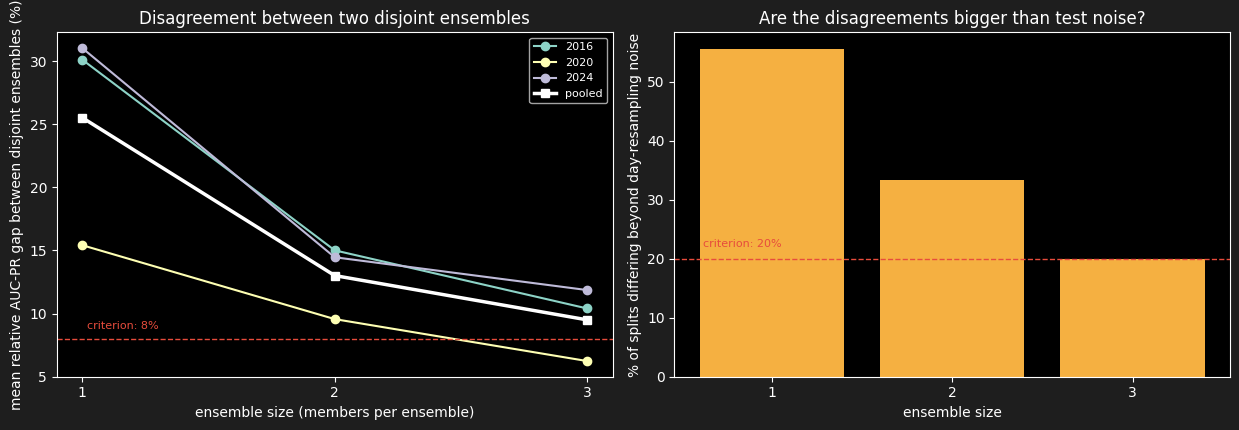

gap x size (a 1/k scaling would keep this constant): {1: np.float64(25.5), 2: np.float64(26.0), 3: np.float64(28.5)}


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ks = [1, 2, 3]
for r in ER:
    axes[0].plot(ks, [100 * r["splits"][str(k)]["mean_rel_gap"] for k in ks], marker="o", label=str(r["year"]))
axes[0].plot(ks, [stab.loc[k, "mean_gap_%"] for k in ks], marker="s", color="white", lw=2.5, label="pooled")
axes[0].axhline(8, color="#e74c3c", ls="--", lw=1); axes[0].text(1.02, 8.8, "criterion: 8%", color="#e74c3c", fontsize=8)
axes[0].set_xticks(ks); axes[0].set_xlabel("ensemble size (members per ensemble)"); axes[0].set_ylabel("mean relative AUC-PR gap between disjoint ensembles (%)")
axes[0].set_title("Disagreement between two disjoint ensembles"); axes[0].legend(fontsize=8)
axes[1].bar(ks, [stab.loc[k, "beyond_noise_%"] for k in ks], color="#f5b041")
axes[1].axhline(20, color="#e74c3c", ls="--", lw=1); axes[1].text(0.62, 22, "criterion: 20%", color="#e74c3c", fontsize=8)
axes[1].set_xticks(ks); axes[1].set_xlabel("ensemble size"); axes[1].set_ylabel("% of splits differing beyond day-resampling noise")
axes[1].set_title("Are the disagreements bigger than test noise?")
plt.tight_layout(); plt.show()
print("gap x size (a 1/k scaling would keep this constant):", {k: round(stab.loc[k, 'mean_gap_%'] * k, 1) for k in ks})

**Reading it.** Disjoint-ensemble disagreement falls from **25.5% (single models) to 13.0% (2 members) to 9.5% (3 members)**, and the share of splits that differ beyond test noise falls from 56% to 33% to 20%.
At 3 members the **criterion is narrowly missed** (9.5% > 8% on the gap; 20% is right at the line on the noise test, and 2024 alone is at 50%). The gap times the ensemble size is roughly constant (25.5 / 26.0 / 28.5), consistent with
disagreement shrinking about as 1/k over this range -- an empirical pattern from three points, **not** a law -- which would put 4 members at ~6-7% and 5-6 members at ~4-5%. That extrapolation cannot be tested with only 6 seeds (disjoint splits stop at 3 + 3).

## 4b. Accuracy and diminishing returns: AUC-PR vs. ensemble size

In [28]:
rows = []
for r in ER:
    sc = r["size_curve"]; m = [sc[str(k)]["mean_ap"] for k in range(1, 7)]
    for k in range(1, 7):
        rows.append({"year": r["year"], "k": k, "mean_AP": m[k - 1], "gain_vs_single_%": 100 * (m[k - 1] / m[0] - 1),
                     "marginal_gain_%": np.nan if k == 1 else 100 * (m[k - 1] / m[k - 2] - 1), "boot_rel_SD_%": 100 * sc[str(k)]["mean_boot_rel_sd"],
                     "rel_SD_across_subsets_%": np.nan if sc[str(k)]["rel_sd_across_subsets"] is None else 100 * sc[str(k)]["rel_sd_across_subsets"]})
curve = pd.DataFrame(rows)
display(curve.pivot(index="k", columns="year", values="mean_AP").round(4))
agg = curve.groupby("k")[["gain_vs_single_%", "marginal_gain_%", "boot_rel_SD_%"]].mean().round(1)
display(agg)

year,2016,2020,2024
k,,,
1,0.0304,0.0423,0.0535
2,0.0370,0.0531,0.0635
3,0.0396,0.0574,0.0668
4,0.0410,0.0598,0.0684
5,0.0418,0.0612,0.0695
6,0.0424,0.0621,0.0703


,gain_vs_single_%,marginal_gain_%,boot_rel_SD_%
k,,,
1,0.0,NaN,18.5
2,22.0,22.0,19.0
3,30.3,6.8,19.2
4,34.7,3.4,19.3
5,37.4,2.0,19.4
6,39.2,1.3,19.5


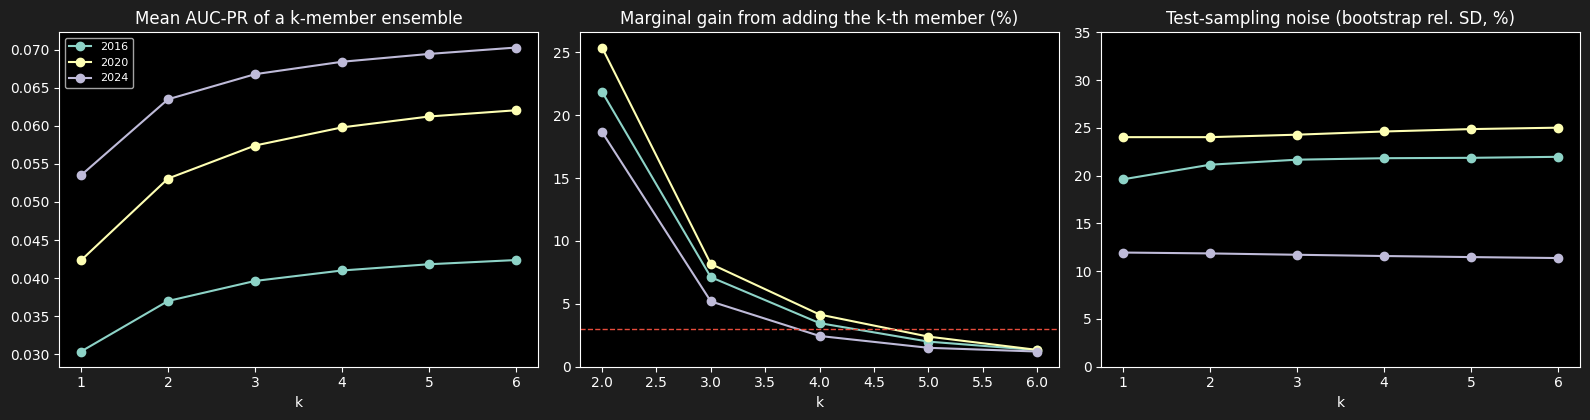

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for yr, g in curve.groupby("year"):
    axes[0].plot(g.k, g["mean_AP"], marker="o", label=str(yr))
    axes[1].plot(g.k[1:], g["marginal_gain_%"][1:], marker="o", label=str(yr))
    axes[2].plot(g.k, g["boot_rel_SD_%"], marker="o", label=str(yr))
axes[0].set_title("Mean AUC-PR of a k-member ensemble"); axes[0].set_xlabel("k"); axes[0].legend(fontsize=8)
axes[1].set_title("Marginal gain from adding the k-th member (%)"); axes[1].set_xlabel("k"); axes[1].axhline(3, color="#e74c3c", ls="--", lw=1)
axes[2].set_title("Test-sampling noise (bootstrap rel. SD, %)"); axes[2].set_xlabel("k"); axes[2].set_ylim(0, 35)
plt.tight_layout(); plt.show()

In [30]:
P2 = {f["year"]: f for f in json.loads((REPO_ROOT / "models" / "seed_study" / "seed_study_results.json").read_text())["folds"]}
OLD_CV_PATH = REPO_ROOT / "models" / "cv_year_holdout" / "results.json"
OLDCV = {f["held_out_year"]: f for f in json.loads(OLD_CV_PATH.read_text())["folds"]}
rows = []
for r in ER:
    fe = r["full_ensemble"]; e3 = P2[r["year"]]["ens_seeds"]["auc_pr"]
    rows.append({"year": r["year"], "mean_single_seed": r["size_curve"]["1"]["mean_ap"], "3-seed ens (seeds 0-2)": e3, "6-seed ens": fe["ap"],
                 "6-seed 95% day-boot CI": f"{fe['ci95'][0]:.4f}-{fe['ci95'][1]:.4f}", "6-seed boot rel SD %": 100 * fe["boot_rel_sd"],
                 "6-seed vs 3-seed %": 100 * (fe["ap"] / e3 - 1), "6-seed vs mean single %": 100 * (fe["ap"] / r["size_curve"]["1"]["mean_ap"] - 1),
                 "orig. single-seed old CV": OLDCV[r["year"]]["auc_pr"]})
display(pd.DataFrame(rows).round(4))

,year,mean_single_seed,3-seed ens (seeds 0-2),6-seed ens,6-seed 95% day-boot CI,6-seed boot rel SD %,6-seed vs 3-seed %,6-seed vs mean single %,orig. single-seed old CV
0,2016,0.0304,0.0388,0.0424,0.0279-0.0640,21.9699,9.2978,39.5953,0.0309
1,2020,0.0423,0.0586,0.0621,0.0340-0.0954,25.0210,5.8540,46.5843,0.0554
2,2024,0.0535,0.0628,0.0703,0.0556-0.0852,11.3742,12.0166,31.3741,0.0486


**Reading it.** Gains over a single seed: **+22% (2 members), +30% (3), +35% (4), +37% (5), +39% (6)**. Each added member contributes less -- **+22%, +6.8%, +3.4%, +2.0%, +1.3%** -- so five members capture
~95% of the gain achievable within this six-seed pool. Test-sampling noise is **identical at every ensemble size (~19%)**: ensembling reduces model variance only. The 6-seed ensembles reach 0.042 / 0.062 / 0.070
on the three folds, +6% to +12% above the 3-seed ensemble from Part 2 and +19% to +54% above the original single-seed CV models, while the day-bootstrap interval of each is still wide (+/-25-45% relative).

## Verdicts on the pre-registered predictions

| # | prediction | verdict | evidence |
|---|---|---|---|
| 1 | disjoint-split gap ~27% (k=1), ~13% (k=2), ~8% +/-3 (k=3) | **Confirmed** | 25.5% / 13.0% / 9.5% |
| 2 | gain over single ~+20% (2), ~+30% (3), ~+40-45% (6); 5th and 6th members add < 3% each | **Confirmed, 6-member slightly under** | +22% / +30% / +39%; 5th member +2.0%, 6th +1.3% |
| 3 | ensemble test-sampling noise ~ a single model's (+/-2 points) | **Confirmed** | 19% at every ensemble size |
| 4 | 6-seed ensemble >= 3-seed ensemble in >= 2 of 3 folds | **Confirmed (3 of 3)** | +9% / +6% / +12% |

**Criterion** (disjoint ensembles: mean gap <= 8% and <= 20% of splits beyond noise): **3 members narrowly fail** (gap 9.5%; noise test at exactly 20% but 50% in 2024). Per the decision rule written beforehand:
**use >= 5 members** (the gap extrapolates to ~5% and 5 members capture ~95% of the achievable gain), and treat variance reduction at the source as the next experiment.

## Conclusions (Part 4)

1. **Use a 5-member ensemble as the project baseline.** It is the smallest size that (by extrapolation, not by direct test) should satisfy the stability criterion, and it captures ~95% of the accuracy gain available here.
   Three members are a defensible cheaper choice but did not clear the bar.
2. **The headline AUC-PR of the 14-feature U-Net should be quoted as ~0.04-0.07 per fold from a 5-6-member ensemble (+19% to +54% over the original single-seed CV models on these three folds), with the day-bootstrap interval attached** -- a single year's value is still only known to roughly +/-25-45%.
3. **Ensembling cannot fix test-sampling noise** (19% at every size). For comparisons between configurations, use ensembles *and* pool across folds (12-fold means), with paired bootstrap intervals.
4. **Open items:** stability at 4-6 members is extrapolated, not measured (needs >= 8-10 seeds for disjoint 4+4 / 5+5); the criterion thresholds (8% / 20%) were my choice; only 3 folds; the cost of a 12-fold 5-member baseline is ~22-25 h of CPU training
   (the old and v4 seed-0 models already give 2 members per fold, and Part 2 found them exchangeable).

---
# Part 5: Weight averaging (EMA) -- can it reduce the instability at the source?

**Why.** Part 4 settled on a >= 5-member ensemble because single models are unstable (seed spread ~24%), but five models cost five trainings. Weight averaging targets the same
noise differently: instead of averaging the *predictions* of separate models, it averages one model's *own weights* along its late training path, giving a single, steadier model at almost no extra cost.
If it cuts the seed spread, fewer ensemble members may be needed.

**Mechanism.** An exponential moving average (EMA) of the weights, updated after every optimizer step: `ema = d * ema + (1 - d) * weights`, with horizon ~ 1 / (1 - d) steps. Training here is noisy
(batch size 2, a loss driven by a few rare positive cells) and the loss had flattened by ~epoch 5 in earlier runs, so the final weights are one noisy snapshot of a wobble the average should smooth. The U-Net has no
batch-norm or dropout layers, so averaging parameters is exact. Training itself is unchanged (verified by tests: tracking the average does not alter the loss history or the final weights); the option is off by default.

**Design.** Same v4 14-feature U-Net CV recipe, same three folds (2016, 2020, 2024), **new seeds 10, 11, 12**. Each run saves the plain final model (**raw**) and the averaged model at decay **0.9999** (primary;
~10,000-step horizon ~ 4 epochs of ~2,500 steps) and **0.999** (exploratory; ~1,000 steps ~ 0.4 epoch). Because raw and EMA come from the *same* run, raw-vs-EMA is a **paired** comparison.
~47 min per run, 9 runs (~7 h). Scripts: `scripts/run_ema_study.sh`, `scripts/ema_eval.py`; code: `training.train_model(ema_decays=...)`, `cross_validate_year.py --ema-decays`. The three raw models also add three plain seeds
to the pool on these folds (9 plain seeds in total).

**Pass/fail criteria, fixed before looking** (primary variant EMA 0.9999 vs. raw, same runs):
- **C1, instability:** mean within-fold seed CV of AUC-PR for EMA models <= **0.5 x** the raw models' CV (measured on these same seeds, not assumed) **and** <= 12%.
- **C2, accuracy preserved:** pooled mean AUC-PR over the 9 runs: EMA >= **0.95 x** raw.
- **C3, paired direction:** EMA AUC-PR >= raw in >= **6 of 9** runs.
- **C4, disjoint-pair disagreement:** mean relative gap between two EMA models <= **0.6 x** that between two raw models.

**Outcomes.** *Works* = C1 + C2 + C4 -> adopt EMA models; test whether 3 EMA members meet the Part 4 stability criterion (needs 3 more seeds for a disjoint 3-vs-3 test).
*Partial* = C2 holds and the seed CV falls by 20-50% -> adopt EMA and still use >= 5 members. *No help* = anything else -> plain 5-member ensemble.

**My prediction:** a *partial* outcome -- EMA 0.9999 reducing the seed CV from ~24% to ~15%, AUC-PR within +/- 5% of raw, and EMA 0.999 helping less. Caveat in advance: with 3 seeds per fold the CV itself is noisy (6 degrees of freedom), so the
paired and pooled comparisons carry more weight than any single fold's CV.

In [31]:
EMA_PATH = REPO_ROOT / "models" / "ema_study" / "ema_eval.json"
EV = json.loads(EMA_PATH.read_text())
E8_PATH = REPO_ROOT / "models" / "seed_study" / "ensemble_size_8seeds.json"
E8 = json.loads(E8_PATH.read_text())
print("EMA study folds:", [(f["year"], f["variants"]["raw"]["seeds"]) for f in EV])

EMA study folds: [(2016, [10, 11, 12]), (2020, [10, 11, 12]), (2024, [10, 11, 12])]


## 5a. Per-run results: plain (raw) vs. weight-averaged models, same training runs

In [32]:
rows = []
for f in EV:
    for v in ("raw", "ema0.9999", "ema0.999"):
        r = f["variants"][v]
        rows.append({"year": f["year"], "variant": v, "AP_seeds": [round(a, 4) for a in r["aps"]], "mean_AP": r["mean_ap"], "seed_CV_%": 100 * r["cv"],
                     "mean_pair_gap_%": 100 * r["mean_pair_gap"], "pairs_beyond_noise": f'{r["pairs_beyond_noise"]}/{r["n_pairs"]}',
                     "3-member_ens_AP": r["ens"]["ap"]})
evt = pd.DataFrame(rows)
display(evt.round(4))
pr = pd.DataFrame([{"year": f["year"], **p} for f in EV for p in f["paired_raw_vs_ema"]])
pr["rel_change_%"] = 100 * pr.rel_change
display(pr[pr.variant == "ema0.9999"][["year", "seed", "raw_ap", "ema_ap", "rel_change_%", "ci95_diff", "excludes_zero"]].round(4))

,year,variant,AP_seeds,mean_AP,seed_CV_%,mean_pair_gap_%,pairs_beyond_noise,3-member_ens_AP
0,2016,raw,"[0.0328, 0.0381, 0.0383]",0.0364,8.6206,10.4193,1/3,0.0415
1,2016,ema0.9999,"[0.0333, 0.0325, 0.0334]",0.0331,1.5001,1.8799,0/3,0.0389
2,2016,ema0.999,"[0.0332, 0.0392, 0.0354]",0.0360,8.4904,11.1303,1/3,0.0411
3,2020,raw,"[0.052, 0.0412, 0.0439]",0.0457,12.1875,15.3475,2/3,0.0549
4,2020,ema0.9999,"[0.0486, 0.0482, 0.0525]",0.0497,4.7756,5.6918,0/3,0.0571
5,2020,ema0.999,"[0.0504, 0.0436, 0.0477]",0.0473,7.2347,9.6344,0/3,0.0555
6,2024,raw,"[0.0571, 0.0669, 0.0555]",0.0598,10.2779,12.3566,1/3,0.0726
7,2024,ema0.9999,"[0.0663, 0.0631, 0.0602]",0.0632,4.8194,6.4231,0/3,0.0726
8,2024,ema0.999,"[0.0677, 0.0656, 0.0586]",0.0640,7.4978,9.6815,1/3,0.0730


,year,seed,raw_ap,ema_ap,rel_change_%,ci95_diff,excludes_zero
0,2016,10,0.0328,0.0333,1.5725,"[-0.0022953819284258757, 0.0028613792324741582]",False
1,2016,11,0.0381,0.0325,-14.5850,"[-0.013843240333090326, 0.0005978946689950599]",False
2,2016,12,0.0383,0.0334,-12.7197,"[-0.010059782789103666, -0.0007515553408569878]",True
6,2020,10,0.0520,0.0486,-6.5287,"[-0.009512923629816445, 0.0020747679469501554]",False
7,2020,11,0.0412,0.0482,16.8019,"[6.741675084180223e-06, 0.014973353650944661]",True
8,2020,12,0.0439,0.0525,19.3914,"[0.0020949360672722476, 0.014462631624705301]",True
12,2024,10,0.0571,0.0663,16.1115,"[0.003101539477791508, 0.014918427905005648]",True
13,2024,11,0.0669,0.0631,-5.6011,"[-0.010223528456018025, 0.0021991219303087485]",False
14,2024,12,0.0555,0.0602,8.3712,"[-0.0003911036743611334, 0.009144042962725042]",False


## 5b. The pre-registered criteria

In [33]:
def criteria(v):
    cvr = [f["variants"]["raw"]["cv"] for f in EV]; cve = [f["variants"][v]["cv"] for f in EV]
    raw_ap = np.array([a for f in EV for a in f["variants"]["raw"]["aps"]]); ema_ap = np.array([a for f in EV for a in f["variants"][v]["aps"]])
    gr = [f["variants"]["raw"]["mean_pair_gap"] for f in EV]; ge = [f["variants"][v]["mean_pair_gap"] for f in EV]
    wins = int((pr[pr.variant == v].rel_change >= 0).sum()); n = int((pr.variant == v).sum())
    out = {
        "C1 seed CV <= 0.5x raw and <= 12%": (np.mean(cve) <= 0.5 * np.mean(cvr) and np.mean(cve) <= 0.12, f"raw {100*np.mean(cvr):.1f}% -> EMA {100*np.mean(cve):.1f}% (ratio {np.mean(cve)/np.mean(cvr):.2f})"),
        "C2 pooled AP >= 0.95x raw": (ema_ap.mean() >= 0.95 * raw_ap.mean(), f"raw {raw_ap.mean():.4f} -> EMA {ema_ap.mean():.4f} (ratio {ema_ap.mean()/raw_ap.mean():.3f})"),
        "C3 EMA >= raw in >= 6/9 runs": (wins >= 6, f"{wins}/{n} runs; per-run changes {[round(100*r) for r in pr[pr.variant == v].rel_change]}%"),
        "C4 pair gap <= 0.6x raw": (np.mean(ge) <= 0.6 * np.mean(gr), f"raw {100*np.mean(gr):.1f}% -> EMA {100*np.mean(ge):.1f}% (ratio {np.mean(ge)/np.mean(gr):.2f}); pairs beyond noise raw {sum(f['variants']['raw']['pairs_beyond_noise'] for f in EV)}/9 -> EMA {sum(f['variants'][v]['pairs_beyond_noise'] for f in EV)}/9"),
    }
    return out
for v in ("ema0.9999", "ema0.999"):
    print(f"=== {v} {'(PRIMARY)' if v == 'ema0.9999' else '(exploratory)'} ===")
    for k, (ok, msg) in criteria(v).items():
        print(f"  [{'PASS' if ok else 'FAIL'}] {k}: {msg}")

=== ema0.9999 (PRIMARY) ===
  [PASS] C1 seed CV <= 0.5x raw and <= 12%: raw 10.4% -> EMA 3.7% (ratio 0.36)
  [PASS] C2 pooled AP >= 0.95x raw: raw 0.0473 -> EMA 0.0487 (ratio 1.029)
  [FAIL] C3 EMA >= raw in >= 6/9 runs: 5/9 runs; per-run changes [2, -15, -13, -7, 17, 19, 16, -6, 8]%
  [PASS] C4 pair gap <= 0.6x raw: raw 12.7% -> EMA 4.7% (ratio 0.37); pairs beyond noise raw 4/9 -> EMA 0/9
=== ema0.999 (exploratory) ===
  [FAIL] C1 seed CV <= 0.5x raw and <= 12%: raw 10.4% -> EMA 7.7% (ratio 0.75)
  [PASS] C2 pooled AP >= 0.95x raw: raw 0.0473 -> EMA 0.0491 (ratio 1.037)
  [PASS] C3 EMA >= raw in >= 6/9 runs: 6/9 runs; per-run changes [1, 3, -7, -3, 6, 9, 19, -2, 5]%
  [FAIL] C4 pair gap <= 0.6x raw: raw 12.7% -> EMA 10.1% (ratio 0.80); pairs beyond noise raw 4/9 -> EMA 2/9


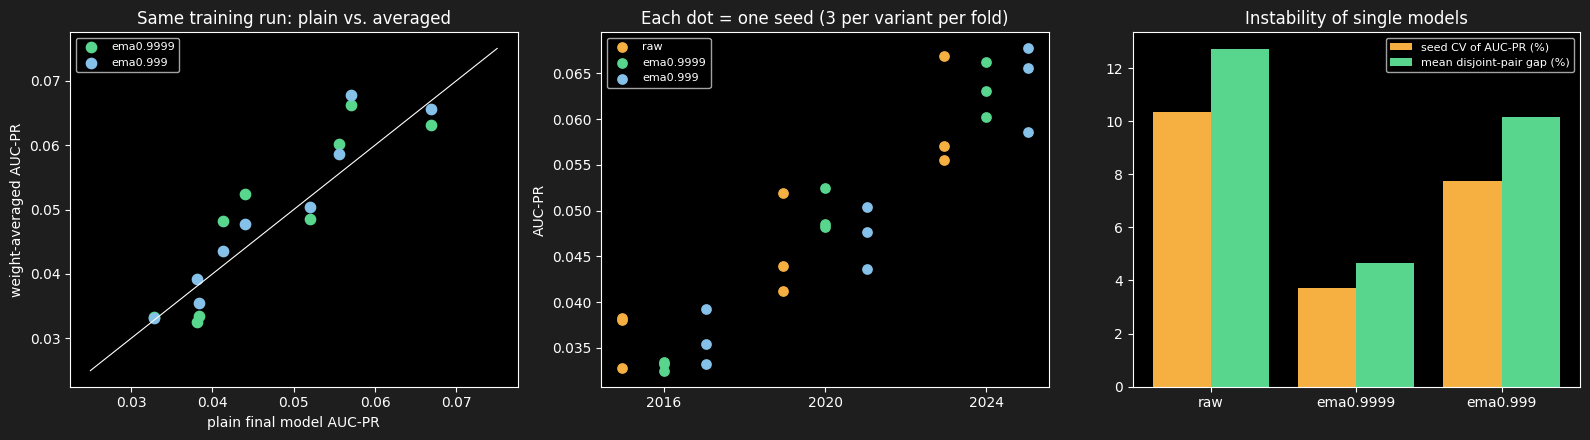

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# (1) paired raw vs EMA per run
for v, col in (("ema0.9999", "#58d68d"), ("ema0.999", "#85c1e9")):
    d = pr[pr.variant == v]
    axes[0].scatter(d.raw_ap, d.ema_ap, color=col, s=55, label=v)
lim = [0.025, 0.075]; axes[0].plot(lim, lim, color="white", lw=0.8)
axes[0].set_xlabel("plain final model AUC-PR"); axes[0].set_ylabel("weight-averaged AUC-PR"); axes[0].set_title("Same training run: plain vs. averaged"); axes[0].legend(fontsize=8)
# (2) AP of each run by fold and variant
x = np.arange(3); w = 0.26
for off, v, col in ((-w, "raw", C_NEW), (0, "ema0.9999", "#58d68d"), (w, "ema0.999", "#85c1e9")):
    for j, f in enumerate(EV):
        axes[1].scatter([j + off] * 3, f["variants"][v]["aps"], color=col, s=45, label=v if j == 0 else None)
axes[1].set_xticks(x); axes[1].set_xticklabels([f["year"] for f in EV]); axes[1].set_title("Each dot = one seed (3 per variant per fold)"); axes[1].set_ylabel("AUC-PR"); axes[1].legend(fontsize=8)
# (3) seed CV and pair gap
labs = ["raw", "ema0.9999", "ema0.999"]
axes[2].bar(np.arange(3) - 0.2, [100 * np.mean([f["variants"][v]["cv"] for f in EV]) for v in labs], 0.4, color="#f5b041", label="seed CV of AUC-PR (%)")
axes[2].bar(np.arange(3) + 0.2, [100 * np.mean([f["variants"][v]["mean_pair_gap"] for f in EV]) for v in labs], 0.4, color="#58d68d", label="mean disjoint-pair gap (%)")
axes[2].set_xticks(range(3)); axes[2].set_xticklabels(labs); axes[2].legend(fontsize=8); axes[2].set_title("Instability of single models")
plt.tight_layout(); plt.show()

**Reading it.** On the primary variant (decay 0.9999) the seed CV falls **10.4% -> 3.7%** (ratio 0.36), the disjoint-pair gap **12.7% -> 4.7%** (ratio 0.37), and pairs that differ beyond test noise go from **4 of 9 to 0 of 9**, with the pooled mean AUC-PR **unchanged to slightly higher (+2.9%)**.
C1, C2 and C4 pass. **C3 fails (5 of 9 runs improve; the threshold was 6):** averaging does not make each individual model better -- it moves models toward a common value (individual runs change by -15% to +19%, with the above-average ones coming down and below-average ones going up), which reduces spread without raising the mean.
That is what variance reduction looks like, but it means "EMA is better per run" is *not* what we found. The faster 0.999 average (about 0.4 epoch) helps much less (CV 10.4% -> 7.7%; C1 and C4 fail) -- consistent with the smoothing needing a horizon of several epochs.

## 5c. Recalibration: a better estimate of plain-model seed spread, and a direct 4-member stability test

The first seed-spread estimate (~24%, Parts 2-3) came from seeds 0-2 on three folds *selected* for large v4-vs-old gaps. We now have nine plain seeds per fold (0-5 from Parts 2/4, and the raw models of seeds 10-12 from this study; seed 0 is the selection-affected one).

In [35]:
P2 = {f["year"]: f for f in json.loads((REPO_ROOT / "models" / "seed_study" / "seed_study_results.json").read_text())["folds"]}
def plain_seeds(year):
    d = {"s0": P2[year]["seed0"]["auc_pr"], "s1": P2[year]["seed1"]["auc_pr"], "s2": P2[year]["seed2"]["auc_pr"]}
    for s in (3, 4, 5):
        d[f"s{s}"] = [x for x in json.loads((REPO_ROOT / "models" / "seed_study" / f"seed{s}" / "results.json").read_text())["folds"] if x["held_out_year"] == year][0]["auc_pr"]
    ef = [x for x in EV if x["year"] == year][0]["variants"]["raw"]
    for s, a in zip(ef["seeds"], ef["aps"]):
        d[f"s{s}"] = a
    return d
rows, var9, var8, mean9, mean8 = [], [], [], [], []
for yr in (2016, 2020, 2024):
    d = plain_seeds(yr); a9 = np.array(list(d.values())); a8 = np.array([v for k, v in d.items() if k != "s0"])
    rows.append({"year": yr, "CV_all_9_%": 100 * a9.std(ddof=1) / a9.mean(), "CV_excl_seed0_(8)_%": 100 * a8.std(ddof=1) / a8.mean(),
                 "CV_seeds_0-2_%": 100 * a9[:3].std(ddof=1) / a9[:3].mean(), "CV_seeds_3-5_%": 100 * a9[3:6].std(ddof=1) / a9[3:6].mean(), "CV_seeds_10-12_%": 100 * a9[6:].std(ddof=1) / a9[6:].mean()})
    var9.append(a9.var(ddof=1)); var8.append(a8.var(ddof=1)); mean9.append(a9.mean()); mean8.append(a8.mean())
display(pd.DataFrame(rows).round(1))
rel9 = np.sqrt(np.mean(var9)) / np.mean(mean9); rel8 = np.sqrt(np.mean(var8)) / np.mean(mean8)
print(f"pooled relative seed SD: all 9 plain seeds {100*rel9:.1f}%;  excluding seed 0 (8 seeds) {100*rel8:.1f}%   (earlier estimate from seeds 0-2: ~24-28%)")
for label, n in (("single seed per fold, 12 folds", 12), ("3 seeds per fold, 12 folds", 36)):
    se = np.sqrt(2) * rel9 / np.sqrt(n)
    print(f"  {label:32s}: SE of mean relative diff ~{100*se:.1f}% -> min detectable effect (80% power) ~{100*2.8*se:.0f}%")
print("Note how much 3-seed CVs vary by seed group (9% to 34%): a CV from only 3 seeds is itself very noisy -- one reason the pooled estimate matters.")

,year,CV_all_9_%,CV_excl_seed0_(8)_%,CV_seeds_0-2_%,CV_seeds_3-5_%,CV_seeds_10-12_%
0,2016,21.2,22.4,21.8,31.4,8.6
1,2020,12.2,12.1,16.4,8.8,12.2
2,2024,20.4,21.4,34.5,14.7,10.3


pooled relative seed SD: all 9 plain seeds 18.8%;  excluding seed 0 (8 seeds) 19.5%   (earlier estimate from seeds 0-2: ~24-28%)
  single seed per fold, 12 folds  : SE of mean relative diff ~7.7% -> min detectable effect (80% power) ~21%
  3 seeds per fold, 12 folds      : SE of mean relative diff ~4.4% -> min detectable effect (80% power) ~12%
Note how much 3-seed CVs vary by seed group (9% to 34%): a CV from only 3 seeds is itself very noisy -- one reason the pooled estimate matters.


In [36]:
rows = []
for k in ("1", "2", "3", "4"):
    allg = [d["rel_gap"] for r in E8 for d in r["splits"][k]["detail"]]
    beyond = sum(d["excludes_zero"] for r in E8 for d in r["splits"][k]["detail"])
    rows.append({"ensemble_size": int(k), "n_splits": len(allg), "mean_gap_%": 100 * np.mean(allg), "beyond_noise_%": 100 * beyond / len(allg),
                 **{f"gap_{r['year']}_%": 100 * r["splits"][k]["mean_rel_gap"] for r in E8}, **{f"beyond_{r['year']}_%": 100 * r["splits"][k]["frac_beyond_noise"] for r in E8},
                 "gain_vs_single_%": 100 * np.mean([r["size_curve"][k]["mean_ap"] / r["size_curve"]["1"]["mean_ap"] - 1 for r in E8])})
st8 = pd.DataFrame(rows).set_index("ensemble_size")
display(st8.round(1))
print("8 unselected plain seeds (1-5, 10-12); disjoint plain ensembles. Criterion: mean gap <= 8% AND <= 20% of splits beyond day-resampling noise")
for k in (1, 2, 3, 4):
    g, b = st8.loc[k, "mean_gap_%"], st8.loc[k, "beyond_noise_%"]
    print(f"  k={k}: gap {g:.1f}% [{'ok' if g <= 8 else 'FAIL'}], beyond noise {b:.0f}% [{'ok' if b <= 20 else 'FAIL'}]")
print("full 8-seed ensemble gain over a single seed, per fold:", [f"{100*(r['full_ensemble']['ap']/r['size_curve']['1']['mean_ap']-1):+.0f}%" for r in E8],
      " AP:", [round(r['full_ensemble']['ap'], 4) for r in E8])
# EMA single models vs. plain disjoint ensembles
ema_gap = np.mean([f["variants"]["ema0.9999"]["mean_pair_gap"] for f in EV]); raw_gap = np.mean([f["variants"]["raw"]["mean_pair_gap"] for f in EV])
print(f"\nfor scale: EMA(0.9999) single-model pair gap {100*ema_gap:.1f}% (same-seed raw pair gap {100*raw_gap:.1f}%; the 8-seed plain pool's single-model gap is {st8.loc[1,'mean_gap_%']:.1f}%);"
      f" 4-member plain ensembles: {st8.loc[4,'mean_gap_%']:.1f}%")

,n_splits,mean_gap_%,beyond_noise_%,gap_2016_%,gap_2020_%,gap_2024_%,beyond_2016_%,beyond_2020_%,beyond_2024_%,gain_vs_single_%
ensemble_size,,,,,,,,,,
1,84,22.5,50.0,27.4,14.7,25.5,67.9,25.0,57.1,0.0
2,630,11.3,30.3,12.8,8.6,12.4,35.7,8.6,46.7,18.7
3,840,9.2,26.4,8.8,8.1,10.6,23.2,9.3,46.8,25.4
4,105,8.2,24.8,6.9,7.9,9.9,14.3,11.4,48.6,29.0


8 unselected plain seeds (1-5, 10-12); disjoint plain ensembles. Criterion: mean gap <= 8% AND <= 20% of splits beyond day-resampling noise
  k=1: gap 22.5% [FAIL], beyond noise 50% [FAIL]
  k=2: gap 11.3% [FAIL], beyond noise 30% [FAIL]
  k=3: gap 9.2% [FAIL], beyond noise 26% [FAIL]
  k=4: gap 8.2% [FAIL], beyond noise 25% [FAIL]
full 8-seed ensemble gain over a single seed, per fold: ['+35%', '+36%', '+33%']  AP: [0.043, 0.0598, 0.0726]

for scale: EMA(0.9999) single-model pair gap 4.7% (same-seed raw pair gap 12.7%; the 8-seed plain pool's single-model gap is 22.5%); 4-member plain ensembles: 8.2%


**Reading it.** (1) **Plain-model seed spread is ~19%, not ~24%.** Pooling all nine plain seeds gives 18.8% (19.5% without seed 0); 3-seed groups range from 9% to 34%, so the earlier estimate was inflated by fold selection plus the noise of a 3-seed CV.
The minimum effect detectable by a single-seed 12-fold comparison is therefore ~21% (not ~32%), or ~12% with 3 seeds per fold.
(2) **The direct 4-member test is a near miss, not the extrapolated pass.** With eight unselected seeds, disjoint plain ensembles disagree by **22.5% / 11.3% / 9.2% / 8.2%** at 1 / 2 / 3 / 4 members, with 50% / 30% / 26% / 25% of splits beyond test noise (2024 alone ~49% at k = 4):
the gap flattens rather than falling as 1/k (my earlier extrapolation of ~6-7% at k = 4 was too optimistic). The gain over a single seed keeps rising: +19% / +25% / +29% at 2 / 3 / 4 members and **+33-36% for the full 8** -- so the 6-seed "5 members capture ~95%" statement was relative to that small pool; at 8 seeds, 4 members capture ~83% of the 8-member gain.
(3) **A single EMA(0.9999) model agrees with another one better (4.7% gap) than two disjoint 4-member plain ensembles do (8.2%)** -- but the comparison mixes different seed sets (EMA seeds 10-12 were a tighter-than-typical trio: their raw pair gap was 12.7%, not the pool's 22.5%), so the like-for-like ratio is the paired 0.37, which scales the pool's 22.5% to ~8%: roughly the stability of a 4-member plain ensemble from one model.

## Verdict (Part 5)

**UPDATE (Part 6a): with six seeds per fold this verdict is revised from "works" to "partial"** -- the 9-run ratios below (0.36 / 0.37) shrink to 0.66 / 0.65 with 18 runs, and C1 and C4 then fail. The text below is kept as recorded at the time.

- **Pre-registered outcome: "works"** (C1, C2, C4 pass for EMA 0.9999; C3 fails at 5/9). Averaging the weights over the last ~4 epochs cuts the seed-to-seed spread and the pair disagreement by ~60%, drives disagreement between runs to within test-sampling noise
  (0/9 pairs beyond noise vs. 4/9), and does not reduce accuracy (pooled AUC-PR +2.9%). It does **not** improve individual runs reliably, and the faster 0.999 average mostly does not help.
- **Prediction check:** I predicted a *partial* outcome (CV ~24% -> ~15%). The result is *stronger* than predicted on the paired comparison (ratio 0.36), but the baseline moved: the plain CV on these seeds was 10%, and the pooled plain CV is ~19%, so my "24%" starting point was itself wrong.
- **Plan implied:** EMA is cheap (no extra forward passes) and should be adopted for every member. Whether *3 EMA members* meet the Part 4 stability criterion is **untested**: it needs six EMA models per fold for a disjoint 3-vs-3 split
  (three more seeds, ~7 h); plain ensembles need >= 5 members and still sit near the line at 4 (8.2%).
- **What this does to earlier numbers:** seed noise is ~19% (not ~24%), minimum detectable effect ~21% single-seed (~12% with 3 seeds per fold); the ensemble-size gains from the 6-seed pool (+22/+30/+35/+37/+39%) were slightly high versus the 8 unselected seeds (+19/+25/+29% at 2/3/4 members, +33-36% at 8). Parts 2-4 stand as measured at the time; this section supersedes the specific numbers.

**Limits.** 3 seeds x 3 folds per variant (the EMA CV rests on 6 degrees of freedom); only two decay values, chosen a priori (no tuning); the averaged models' accuracy gain is small and not significant; no disjoint-ensemble test for EMA yet; the k = 4 test has only 35 splits per fold,
all drawn from the same 8 models (not independent).

---
# Part 6: Do three weight-averaged members make a stable ensemble?

**Why.** Part 5 found weight averaging (EMA, decay 0.9999) makes each model far steadier (seed spread and disjoint-pair disagreement down ~60%), while plain ensembles still sit just short of the
stability criterion at four members (gap 8.2%). The practical question is the **smallest ensemble of averaged models that meets the criterion**. The Part 4 test needs two *disjoint* ensembles, so 3 + 3 members means six averaged models per fold.

**Design.** Three more seeds (13, 14, 15) of the v4 14-feature U-Net CV recipe with EMA 0.9999 on the same three folds (2016, 2020, 2024), giving **six averaged models and six plain models per fold from the same six
training runs (seeds 10-15)**. About 47 min per run, 9 runs (~7 h). Analysis (`scripts/ensemble_size.py --emastudy-variant ...`): every-subset ensembles, disjoint splits for 1 vs 1, 2 vs 2 and 3 vs 3,
the same day-block bootstrap as Parts 3-5, run identically for the averaged and plain models. Because the plain models come from the same runs, plain-vs-averaged is a paired comparison.

**Criterion, unchanged from Part 4:** an ensemble size is stable enough to be the baseline if two disjoint ensembles of that size disagree by **<= 8% on average** (relative AUC-PR gap) and differ beyond day-resampling noise in **<= 20% of splits** (pooled over the three folds).

**Predictions, fixed before looking:**
1. Averaged models, 1 vs 1: mean gap ~5-8% (plain: ~15-22%).
2. **Averaged 3 vs 3 meets the criterion** (gap <= 8% and <= 20% beyond noise); plain 3 vs 3 does not (it was 9.2% in the 8-seed pool).
3. Averaging helps stability but not the accuracy ceiling: the 6-model averaged ensemble's AUC-PR is within +/- 5% of the 6-model plain ensemble's.
4. Ensembling gains less for averaged models than for plain ones (their members are more alike): 3-member gain over a single averaged model ~ +10-18% (plain: ~+25%).

**Decision rule.** If averaged 3 vs 3 meets the criterion, the baseline is **3 averaged members**. If only 2 vs 2 meets it, the baseline is 2 averaged members, and so on down; if none meet it, use 5 averaged members (the test cannot go beyond 3 + 3 with six models).

In [37]:
E6 = json.loads((REPO_ROOT / "models" / "ema_study" / "ema_eval_6seeds.json").read_text())
E6_RAW = json.loads((REPO_ROOT / "models" / "ema_study" / "ens_size_6seeds_raw.json").read_text())
E6_EMA = json.loads((REPO_ROOT / "models" / "ema_study" / "ens_size_6seeds_ema0.9999.json").read_text())
print("six models per fold per variant (seeds 10-15):", [(f["year"], f["variants"]["raw"]["seeds"]) for f in E6][0])

six models per fold per variant (seeds 10-15): (2016, [10, 11, 12, 13, 14, 15])


## 6a. Part 5 re-evaluated with six seeds per fold (18 runs instead of 9)

Same four criteria, same variant (EMA 0.9999 vs. plain, same runs); the C3 threshold is scaled from 6 of 9 to 12 of 18 runs.

In [38]:
cvr = [f["variants"]["raw"]["cv"] for f in E6]; cve = [f["variants"]["ema0.9999"]["cv"] for f in E6]
ra = np.array([a for f in E6 for a in f["variants"]["raw"]["aps"]]); ea = np.array([a for f in E6 for a in f["variants"]["ema0.9999"]["aps"]])
ch = np.array([p["rel_change"] for f in E6 for p in f["paired_raw_vs_ema"] if p["variant"] == "ema0.9999"])
gr = [f["variants"]["raw"]["mean_pair_gap"] for f in E6]; ge = [f["variants"]["ema0.9999"]["mean_pair_gap"] for f in E6]
npairs = sum(f["variants"]["raw"]["n_pairs"] for f in E6)
br = sum(f["variants"]["raw"]["pairs_beyond_noise"] for f in E6); be = sum(f["variants"]["ema0.9999"]["pairs_beyond_noise"] for f in E6)
res = [
    ("C1 seed CV <= 0.5x raw and <= 12%", np.mean(cve) <= 0.5 * np.mean(cvr) and np.mean(cve) <= 0.12, f"raw {100*np.mean(cvr):.1f}% -> EMA {100*np.mean(cve):.1f}% (ratio {np.mean(cve)/np.mean(cvr):.2f})   [9-run version was 10.4% -> 3.7%, ratio 0.36]"),
    ("C2 pooled AP >= 0.95x raw", ea.mean() >= 0.95 * ra.mean(), f"raw {ra.mean():.4f} -> EMA {ea.mean():.4f} (ratio {ea.mean()/ra.mean():.3f})"),
    ("C3 EMA >= raw in >= 12/18 runs", (ch >= 0).sum() >= 12, f"{int((ch >= 0).sum())}/18 runs; changes {[round(100*c) for c in ch]}%"),
    ("C4 pair gap <= 0.6x raw", np.mean(ge) <= 0.6 * np.mean(gr), f"raw {100*np.mean(gr):.1f}% -> EMA {100*np.mean(ge):.1f}% (ratio {np.mean(ge)/np.mean(gr):.2f}); pairs beyond noise raw {br}/{npairs} -> EMA {be}/{npairs}   [9-run version: 4/9 -> 0/9]"),
]
for k, ok, msg in res:
    print(f"[{'PASS' if ok else 'FAIL'}] {k}: {msg}")
rows = []
for f in E6:
    for v in ("raw", "ema0.9999"):
        r = f["variants"][v]; rows.append({"year": f["year"], "variant": v, "AP_seeds_10-15": [round(a, 4) for a in r["aps"]], "seed_CV_%": 100 * r["cv"], "mean_pair_gap_%": 100 * r["mean_pair_gap"], "pairs_beyond_noise": f'{r["pairs_beyond_noise"]}/{r["n_pairs"]}'})
display(pd.DataFrame(rows).round(3))

[FAIL] C1 seed CV <= 0.5x raw and <= 12%: raw 16.3% -> EMA 10.8% (ratio 0.66)   [9-run version was 10.4% -> 3.7%, ratio 0.36]
[PASS] C2 pooled AP >= 0.95x raw: raw 0.0454 -> EMA 0.0479 (ratio 1.055)
[PASS] C3 EMA >= raw in >= 12/18 runs: 13/18 runs; changes [2, -15, -13, 4, 3, 38, -7, 17, 19, -10, 3, 17, 16, -6, 8, 27, 2, 12]%
[FAIL] C4 pair gap <= 0.6x raw: raw 19.5% -> EMA 12.7% (ratio 0.65); pairs beyond noise raw 17/45 -> EMA 16/45   [9-run version: 4/9 -> 0/9]


,year,variant,AP_seeds_10-15,seed_CV_%,mean_pair_gap_%,pairs_beyond_noise
0,2016,raw,"[0.0328, 0.0381, 0.0383, 0.0345, 0.0387, 0.0192]",22.155,26.427,7/15
1,2016,ema0.9999,"[0.0333, 0.0325, 0.0334, 0.0359, 0.0399, 0.0265]",13.006,15.464,8/15
2,2020,raw,"[0.052, 0.0412, 0.0439, 0.0498, 0.0484, 0.0472]",8.322,10.343,2/15
3,2020,ema0.9999,"[0.0486, 0.0482, 0.0525, 0.0448, 0.0498, 0.0554]",7.364,8.930,3/15
4,2024,raw,"[0.0571, 0.0669, 0.0555, 0.0363, 0.06, 0.0578]",18.441,21.633,8/15
5,2024,ema0.9999,"[0.0663, 0.0631, 0.0602, 0.0461, 0.0613, 0.0646]",12.044,13.591,5/15


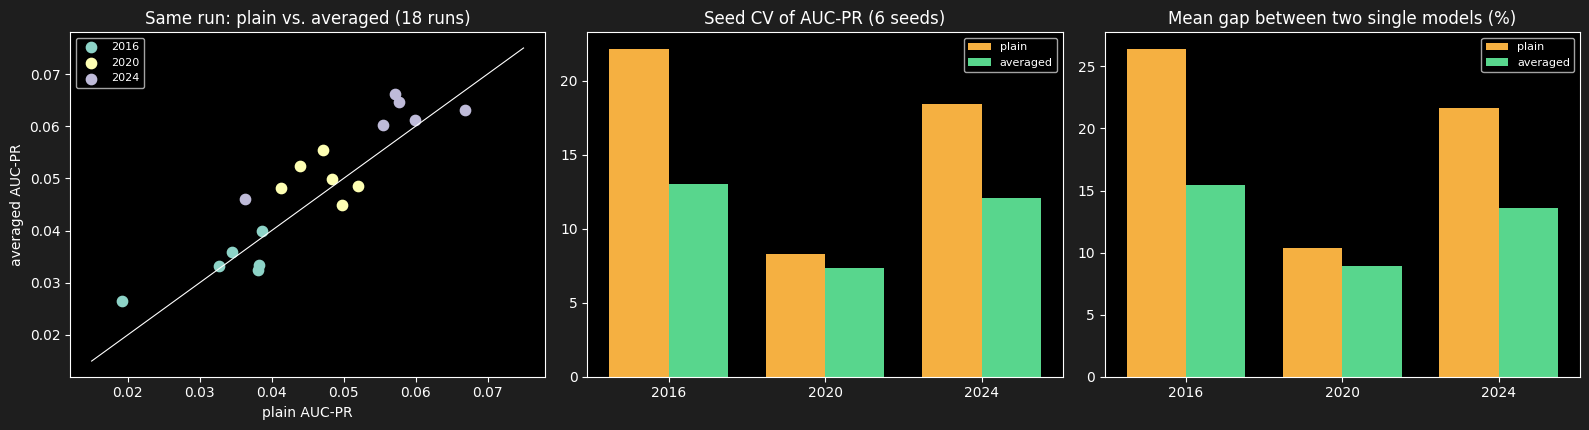

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
d = pd.DataFrame([{"year": f["year"], **p} for f in E6 for p in f["paired_raw_vs_ema"] if p["variant"] == "ema0.9999"])
for yr, g in d.groupby("year"):
    axes[0].scatter(g.raw_ap, g.ema_ap, s=55, label=str(yr))
lim = [0.015, 0.075]; axes[0].plot(lim, lim, color="white", lw=0.8); axes[0].set_xlabel("plain AUC-PR"); axes[0].set_ylabel("averaged AUC-PR")
axes[0].set_title("Same run: plain vs. averaged (18 runs)"); axes[0].legend(fontsize=8)
x = np.arange(3); w = 0.38
axes[1].bar(x - w/2, [100 * f["variants"]["raw"]["cv"] for f in E6], w, color=C_NEW, label="plain"); axes[1].bar(x + w/2, [100 * f["variants"]["ema0.9999"]["cv"] for f in E6], w, color="#58d68d", label="averaged")
axes[1].set_xticks(x); axes[1].set_xticklabels([f["year"] for f in E6]); axes[1].set_title("Seed CV of AUC-PR (6 seeds)"); axes[1].legend(fontsize=8)
axes[2].bar(x - w/2, [100 * f["variants"]["raw"]["mean_pair_gap"] for f in E6], w, color=C_NEW, label="plain"); axes[2].bar(x + w/2, [100 * f["variants"]["ema0.9999"]["mean_pair_gap"] for f in E6], w, color="#58d68d", label="averaged")
axes[2].set_xticks(x); axes[2].set_xticklabels([f["year"] for f in E6]); axes[2].set_title("Mean gap between two single models (%)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading it.** With the larger sample the Part 5 picture shrinks. Averaging still lowers the seed spread (**16.3% -> 10.8%, ratio 0.66**) and the pair gap (**19.5% -> 12.7%, ratio 0.65**), raises the pooled mean AUC-PR (**+5.5%**) and improves 13 of 18 runs --
but **C1 and C4 now fail** against their pre-registered thresholds (0.5x and 0.6x), and the number of single-model pairs that differ beyond test noise is essentially unchanged (**17 of 45 plain vs. 16 of 45 averaged**). The 9-run results (ratio 0.36-0.37, pairs beyond noise 4/9 -> 0/9) were
**optimistic**: seeds 13-15 added low outliers (e.g. 2016 seed 15 = 0.0192 plain, 0.0265 averaged), and the 3-seed CVs behind the earlier ratios were a noisy estimate (flagged then, with 6 degrees of freedom). **Revised Part 5 verdict: partial** -- the outcome I originally predicted.

## 6b. Stability of ensembles: disjoint 1v1, 2v2 and 3v3, plain vs. averaged (the Part 6 test)

In [40]:
rows = []
for name, R in (("plain", E6_RAW), ("averaged (EMA 0.9999)", E6_EMA)):
    for k in ("1", "2", "3"):
        allg = [dd["rel_gap"] for r in R for dd in r["splits"][k]["detail"]]; b = sum(dd["excludes_zero"] for r in R for dd in r["splits"][k]["detail"])
        rows.append({"variant": name, "ensemble_size": int(k), "n_splits": len(allg), "mean_gap_%": 100 * np.mean(allg), "beyond_noise_%": 100 * b / len(allg),
                     "meets_criterion": bool(np.mean(allg) <= 0.08 and b / len(allg) <= 0.20),
                     **{f"gap_{r['year']}_%": 100 * r["splits"][k]["mean_rel_gap"] for r in R}, **{f"beyond_{r['year']}_%": 100 * r["splits"][k]["frac_beyond_noise"] for r in R}})
st6 = pd.DataFrame(rows)
display(st6.round(1))
print("Criterion (pooled over 3 folds): disjoint-ensemble gap <= 8% AND <= 20% of splits beyond day-resampling noise")
for r in st6.itertuples():
    print(f"  {r.variant:22s} k={r.ensemble_size}: gap {r._4:.1f}% | beyond noise {r._5:.1f}% -> {'MEETS' if r.meets_criterion else 'does not meet'}")

,variant,ensemble_size,n_splits,mean_gap_%,beyond_noise_%,meets_criterion,gap_2016_%,gap_2020_%,gap_2024_%,beyond_2016_%,beyond_2020_%,beyond_2024_%
0,plain,1,45,19.5,35.6,False,26.4,10.3,21.6,46.7,13.3,46.7
1,plain,2,135,9.7,22.2,False,9.4,10.0,9.9,26.7,6.7,33.3
2,plain,3,30,8.5,26.7,False,9.0,9.8,6.7,10.0,30.0,40.0
3,averaged (EMA 0.9999),1,45,12.7,33.3,False,15.5,8.9,13.6,53.3,13.3,33.3
4,averaged (EMA 0.9999),2,135,7.4,24.4,False,9.1,6.0,7.0,33.3,11.1,28.9
5,averaged (EMA 0.9999),3,30,6.9,20.0,True,8.0,5.6,7.0,20.0,10.0,30.0


Criterion (pooled over 3 folds): disjoint-ensemble gap <= 8% AND <= 20% of splits beyond day-resampling noise
  plain                  k=1: gap 19.5% | beyond noise 35.6% -> does not meet
  plain                  k=2: gap 9.7% | beyond noise 22.2% -> does not meet
  plain                  k=3: gap 8.5% | beyond noise 26.7% -> does not meet
  averaged (EMA 0.9999)  k=1: gap 12.7% | beyond noise 33.3% -> does not meet
  averaged (EMA 0.9999)  k=2: gap 7.4% | beyond noise 24.4% -> does not meet
  averaged (EMA 0.9999)  k=3: gap 6.9% | beyond noise 20.0% -> MEETS


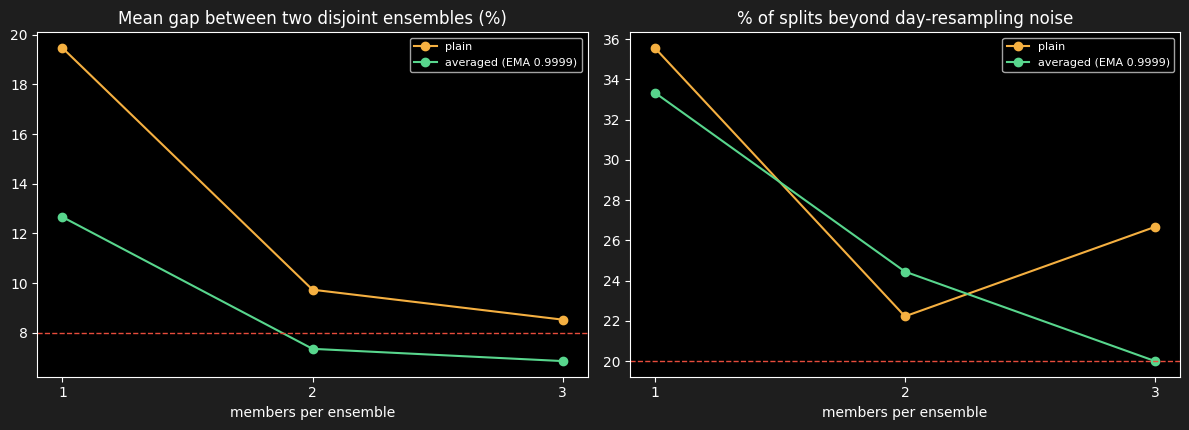

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for name, col in (("plain", C_NEW), ("averaged (EMA 0.9999)", "#58d68d")):
    s_ = st6[st6.variant == name]
    axes[0].plot(s_.ensemble_size, s_["mean_gap_%"], marker="o", color=col, label=name); axes[1].plot(s_.ensemble_size, s_["beyond_noise_%"], marker="o", color=col, label=name)
axes[0].axhline(8, color="#e74c3c", ls="--", lw=1); axes[0].set_title("Mean gap between two disjoint ensembles (%)"); axes[0].set_xticks([1, 2, 3]); axes[0].set_xlabel("members per ensemble"); axes[0].legend(fontsize=8)
axes[1].axhline(20, color="#e74c3c", ls="--", lw=1); axes[1].set_title("% of splits beyond day-resampling noise"); axes[1].set_xticks([1, 2, 3]); axes[1].set_xlabel("members per ensemble"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6c. Accuracy: does averaging raise the ceiling?

In [42]:
rows = []
for name, R in (("plain", E6_RAW), ("averaged", E6_EMA)):
    m = np.array([[r["size_curve"][str(k)]["mean_ap"] for k in range(1, 7)] for r in R])
    rows.append({"variant": name, **{f"AP_k{k}": m.mean(0)[k - 1] for k in range(1, 7)}, **{f"gain_k{k}_%": 100 * (m.mean(0)[k - 1] / m.mean(0)[0] - 1) for k in range(2, 7)}})
display(pd.DataFrame(rows).round(4))
fe = np.array([r["full_ensemble"]["ap"] for r in E6_EMA]); fr = np.array([r["full_ensemble"]["ap"] for r in E6_RAW])
print("6-model ensemble AUC-PR per fold [2016, 2020, 2024]:  averaged", np.round(fe, 4), " plain", np.round(fr, 4), " ratio", np.round(fe / fr, 3), f" pooled ratio {fe.mean()/fr.mean():.3f}")
print("3-member gain over a single model, per fold: plain", [f"{100*(r['size_curve']['3']['mean_ap']/r['size_curve']['1']['mean_ap']-1):+.0f}%" for r in E6_RAW],
      " averaged", [f"{100*(r['size_curve']['3']['mean_ap']/r['size_curve']['1']['mean_ap']-1):+.0f}%" for r in E6_EMA])

,variant,AP_k1,AP_k2,AP_k3,AP_k4,AP_k5,AP_k6,gain_k2_%,gain_k3_%,gain_k4_%,gain_k5_%,gain_k6_%
0,plain,0.0454,0.0536,0.0569,0.0588,0.0601,0.0610,18.0480,25.2907,29.4518,32.2576,34.1929
1,averaged,0.0479,0.0546,0.0568,0.0581,0.0588,0.0593,13.8833,18.6275,21.1742,22.7450,23.8180


6-model ensemble AUC-PR per fold [2016, 2020, 2024]:  averaged [0.0423 0.0601 0.0755]  plain [0.0453 0.065  0.0725]  ratio [0.933 0.925 1.041]  pooled ratio 0.973
3-member gain over a single model, per fold: plain ['+27%', '+26%', '+23%']  averaged ['+21%', '+16%', '+20%']


## Verdicts on the pre-registered predictions (Part 6)

| # | prediction | verdict | evidence |
|---|---|---|---|
| 1 | averaged 1v1 gap ~5-8% (plain ~15-22%) | **Not confirmed** (plain confirmed) | averaged **12.7%**; plain 19.5% -- the 3-seed 4.7% in Part 5 was a lucky trio |
| 2 | averaged 3v3 meets the criterion, plain 3v3 does not | **Confirmed, narrowly** | averaged: gap 6.9%, beyond noise 6/30 = 20.0% (at the line); plain: gap 8.5%, 8/30 = 26.7% |
| 3 | 6-model ceilings within +/-5% of each other | **Partly** | pooled ratio 0.973; per fold 0.93 / 0.93 / 1.04 -- averaging does **not** raise the ceiling (slightly lower in two folds) |
| 4 | averaged ensembles gain less from ensembling (3-member: +10-18% vs. plain ~+25%) | **Confirmed in direction** | averaged +21 / +16 / +20% vs. plain +27 / +26 / +23%; slightly above the predicted range |

## Conclusions (Part 6)

1. **Three averaged members meet the stability criterion (gap 6.9%, 20.0% beyond noise); three plain members do not (8.5%, 26.7%).** The margin is thin -- the noise test is exactly at its limit, and the criterion's thresholds were my choice, so
   treat 3 averaged members as the *minimum*, and 4-5 as the choice when a margin matters. Averaged members are worth roughly one extra plain member in stability (compare plain 4 members: 8.2% in the 8-seed pool).
2. **Revised Part 5: partial.** Averaging reduces single-model seed spread and disagreement by about a third (not ~60%), raises pooled single-model AUC-PR ~5%, but does not make single models interchangeable within test noise; and it does not raise the accuracy of a full ensemble.
   The earlier "works" verdict rested on a lucky three-seed sample; the larger one corrects it. (General lesson, repeated for the third time in this project: a 3-seed estimate of spread is itself unreliable.)
3. **Use averaged (EMA 0.9999) members** -- better single models and better small-ensemble stability at no extra cost -- but do not expect a higher accuracy ceiling than a plain ensemble of the same size.
4. **Cost of a 12-fold baseline:** the nine folds without averaged models need fresh training: 3 members ~ 27 trainings (~21 h), 5 members ~ 45 (~36 h). The plain old/v4 models already in hand cannot be converted to averaged ones.
5. **Limits:** three folds; only 10 disjoint 3v3 splits per fold, all drawn from the same six models; thresholds (8% / 20%) are my own; the 3v3 noise test sits exactly on its limit; averaged-vs-plain is paired by training run but compared at the pooled level.

---
# Part 7: Updraft-helicity re-test with averaged ensembles  *(pending: training in progress)*

**Why.** The original UH ablation was a single seed on a single 3-way split: test AUC-PR 0.0836 -> 0.0491 (-41%) with the UH-augmented 21-feature set, 0.0528 (-37%) with UH 2-5 km only, val -10%. With single-seed noise of ~19% per run
(~27% for a difference of two runs) the test drop is only ~1.5 SD, the val drop ~0.4 SD, and the 0.0836 baseline was itself a flagged lucky draw (92nd percentile of the CV distribution). Whether UH hurts, helps or does nothing is **unresolved**.

**Design.** Year-holdout CV on folds 2016 / 2020 / 2024 (same folds as Parts 2-6), the v4 U-Net recipe with EMA weight averaging (0.9999). **UH-augmented arm:** 14 base features + `uh_2_5km` mean/max (16 features), seeds 10, 11, 12.
**Baseline arm:** the 14-feature averaged models already trained (Part 5/6, seeds 10-15, EMA 0.9999). Both arms use **the same 4,919 runs, train/test splits and 14 base feature values** (verified: base features and labels identical between the
two staged copies; `uh_2_5km` has zero missing values in all 4,918 runs that carry it; one run, 2022-10-14, lacks UH and is zero-filled by the loader -- 2 of ~9,000 training samples, in no test fold). So the comparison isolates the UH features.
Only the cleanest variant, UH 2-5 km, is tested first (the 0-2 / 0-3 km layers are missing before mid-2018, which would confound earlier folds). Scripts: `scripts/run_uh_study.sh` (~50 min/run, 9 runs, ~8 h), `scripts/uh_eval.py`.
(Correction recorded in `CLAUDE.md`: the older 3,182 runs in `scaled_build_v2/` lack UH -- their UH-augmented copies are in `scaled_build_v3/` -- while the 1,737 newer runs carry UH natively; the merged staging set `scaled_build_uh_merged/` uses each run's UH-bearing file.)

**Primary comparison.** The UH 3-member ensemble (seeds 10-12) vs. the distribution of the 20 possible 3-member baseline ensembles drawn from the six baseline models (their spread is the noise floor of a 3-member comparison),
plus the matched baseline triple (seeds 10-12) with a paired day-bootstrap interval. Effect E = UH-ensemble AUC-PR / mean baseline-triple AUC-PR - 1, averaged over the three folds.

**Decision rule, fixed before looking:**
- **UH hurts** if E <= -10% **and** the UH ensemble is below the baseline-triple 10th percentile in >= 2 of 3 folds.
- **UH helps** if E >= +10% **and** above the 90th percentile in >= 2 of 3 folds.
- Otherwise: **no detectable effect (|E| < ~10%)** -- UH is closed as "not shown to matter" and the project keeps the 14 base features (parsimony). (The +/-10% band is ~3 pooled standard errors of a 3-member comparison from the Part 6 triple spread; effects of the size first seen, ~-40%, are well above it.)
- If hurts or helps: extend with seeds 13-15 and test the full 21-feature set; if no effect: stop.

**Predictions, fixed before looking:**
1. **No detectable effect** (|E| < 10%): I expect the original -41% to have been mostly noise plus a lucky baseline, with at most a small true effect.
2. If any effect, it is **slightly negative** (E in [-10%, 0]).
3. The UH ensemble's **Cohen's d is higher** than the baseline ensemble's in >= 2 of 3 folds, reproducing the old pattern in which mean separation rises while AUC-PR does not.
4. Secondary metrics (best-F1, map-level AUC-ROC, 1-cell-dilated AUC-PR) differ from the baseline by < 10% (descriptive only).